### 1. 数据清洗与预处理

#### 导入数据

In [1]:
!pip install -q pandas numpy scipy statsmodels matplotlib

In [2]:
import pandas as pd, numpy as np
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#中文
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="white", font='SimHei') 

In [4]:
pd.set_option('display.max_rows',20)
pd.set_option('display.max_columns',50)

In [5]:
h = pd.read_csv('Medical_Record.csv',low_memory=False)

In [6]:
for i in h.columns:    
    print (i,":",h[i].nunique())

Unnamed: 0 : 79485
PROTOCOL.NUMBER : 79485
OPENING.MEDICAL.RECORD.DATE : 6009
ADMISSION.DATE : 3350
DISCHARGE.FORECAST : 71902
DISCHARGE.DATE : 3528
MEDICAL.RECORD : 51576
AGE : 102
SEX : 2
HOSPITALIZATION.TYPE : 20
SERVICE : 22
1ST.SURGERY.DATE : 61597
NUMBER.OF.SURGERIES : 26
TRANSFER.PLACE : 407
DOCTOR : 391
ICD : 1582
REASON.FOR.DISCHARGE : 14
COMORBIDITIES : 2
DATE.OF.ACCIDENT : 2555
TIME.BETWEEN.INJURY.AND.HOSPITALIZATION : 0


In [7]:
# 读取ICD编码对照表，原始文件无表头（header=None）
# 所有列强制为字符串，避免编码被误识别为数值
# 定义字段：ICD_N一级编码 N-子集索引 ICD_FULL-ICD编码 desc_long 疾病长描述 desc_short 疾病短描述 Type -疾病大类
icd = pd.read_csv('ICD 10 codes.csv', header = None, dtype="string",
                  names = ["ICD_N","N","ICD_full","desc_long","desc_short","Type"]) 
len(h), h.columns.tolist()[:10]

(79485,
 ['Unnamed: 0',
  'PROTOCOL.NUMBER',
  'OPENING.MEDICAL.RECORD.DATE',
  'ADMISSION.DATE',
  'DISCHARGE.FORECAST',
  'DISCHARGE.DATE',
  'MEDICAL.RECORD',
  'AGE',
  'SEX',
  'HOSPITALIZATION.TYPE'])

#### 匹配患者信息与ICD编码

In [8]:
print(icd.head())

  ICD_N  N ICD_full                                          desc_long  \
0   A00  0     A000  Cholera due to Vibrio cholerae 01, biovar chol...   
1   A00  1     A001    Cholera due to Vibrio cholerae 01, biovar eltor   
2   A00  9     A009                               Cholera, unspecified   
3  A010  0    A0100                         Typhoid fever, unspecified   
4  A010  1    A0101                                 Typhoid meningitis   

                                          desc_short           Type  
0  Cholera due to Vibrio cholerae 01, biovar chol...        Cholera  
1    Cholera due to Vibrio cholerae 01, biovar eltor        Cholera  
2                               Cholera, unspecified        Cholera  
3                         Typhoid fever, unspecified  Typhoid fever  
4                                 Typhoid meningitis  Typhoid fever  


In [9]:
h['ICD'] = h['ICD'].astype(str) #指定主要数据集中icd编码的数据类型

In [10]:
print(h['ICD'])

0        D48.0
1        T84.0
2        M84.1
3        M85.5
4        T93.2
         ...  
79480    D16.1
79481    M84.0
79482    T84.0
79483    S82.0
79484    S62.3
Name: ICD, Length: 79485, dtype: object


In [11]:
# 统一清洗和提取 Key
h["ICD_clean"] = h["ICD"].str.upper().str.replace(r"[^A-Z0-9]", "", regex=True)
h["ICD_key4"]  = h["ICD_clean"].str[:4]
h["ICD_key3"]  = h["ICD_clean"].str[:3]

icd["code_clean"] = icd["ICD_full"].str.upper().str.replace(r"[^A-Z0-9]", "", regex=True)
icd["ICD_key4"]   = icd["code_clean"].str[:4]
icd["ICD_key3"]   = icd["code_clean"].str[:3]

map_full = icd.drop_duplicates("code_clean")[["code_clean", "Type", "desc_short", "desc_long"]]\
            .rename(columns={"code_clean": "ICD_clean", "Type": "Type_full", "desc_short": "short_full", "desc_long": "long_full"})

map_4 = icd.drop_duplicates("ICD_key4")[["ICD_key4", "Type", "desc_short", "desc_long"]] \
           .rename(columns={"Type": "Type_4", "desc_short": "short_4", "desc_long": "long_4"})

map_3 = icd.drop_duplicates("ICD_key3")[["ICD_key3", "Type", "desc_short", "desc_long"]] \
           .rename(columns={"Type": "Type_3", "desc_short": "short_3", "desc_long": "long_3"})

# 依次左连
m = h.merge(map_full, on="ICD_clean", how="left") \
     .merge(map_4, on="ICD_key4", how="left") \
     .merge(map_3, on="ICD_key3", how="left")

# 汇总匹配结果
m["Type_final"]       = m["Type_full"].fillna(m["Type_4"]).fillna(m["Type_3"]).fillna("Unmapped/Other")
m["desc_short_final"] = m["short_full"].fillna(m["short_4"]).fillna(m["short_3"]).fillna("Unmapped/Other")
m["desc_long_final"]  = m["long_full"].fillna(m["long_4"]).fillna(m["long_3"]).fillna("Unmapped/Other")

# 记录匹配层级
m["match_level"] = np.select(
    [m["Type_full"].notna(), m["Type_4"].notna(), m["Type_3"].notna()],
    ["full", "4", "3"],
    default="Unmapped"
)

# 整理最终宽表
original_columns = h.columns.tolist()
final_columns = ["Type_final", "desc_short_final", "desc_long_final", "match_level"]
m= m[original_columns + final_columns]

print(m[['ICD', 'Type_final', 'desc_short_final', 'desc_long_final']].head())

     ICD                                         Type_final  \
0  D48.0  Neoplasm of uncertain behavior of other and un...   
1  T84.0               Broken internal right hip prosthesis   
2  M84.1                  Stress fracture, unspecified site   
3  M85.5                               Aneurysmal bone cyst   
4  T93.2                                     Unmapped/Other   

                                    desc_short_final  \
0  Neoplasm of uncertain behavior of bone and art...   
1  Broken internal right hip prosthesis, initial ...   
2  Stress fracture, unspecified site, initial enc...   
3             Aneurysmal bone cyst, unspecified site   
4                                     Unmapped/Other   

                                     desc_long_final  
0  Neoplasm of uncertain behavior of bone/artic c...  
1  Broken internal right hip prosthesis, initial ...  
2  Stress fracture, unspecified site, init encntr...  
3             Aneurysmal bone cyst, unspecified site  
4        

In [12]:
#副本
df = m.copy()

In [13]:
df.info()
df.head()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79485 entries, 0 to 79484
Data columns (total 27 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Unnamed: 0                               79485 non-null  int64  
 1   PROTOCOL.NUMBER                          79485 non-null  int64  
 2   OPENING.MEDICAL.RECORD.DATE              79485 non-null  object 
 3   ADMISSION.DATE                           79485 non-null  object 
 4   DISCHARGE.FORECAST                       78927 non-null  object 
 5   DISCHARGE.DATE                           79426 non-null  object 
 6   MEDICAL.RECORD                           79485 non-null  int64  
 7   AGE                                      79485 non-null  int64  
 8   SEX                                      79485 non-null  object 
 9   HOSPITALIZATION.TYPE                     53447 non-null  object 
 10  SERVICE                                  79485

(79485, 27)

In [14]:
#TIME.BETWEEN.INJURY.AND.HOSPITALIZATION  受伤至住院时间间隔 全部为0

In [15]:
for i in df.columns:
    print (i,":",df[i].nunique())

Unnamed: 0 : 79485
PROTOCOL.NUMBER : 79485
OPENING.MEDICAL.RECORD.DATE : 6009
ADMISSION.DATE : 3350
DISCHARGE.FORECAST : 71902
DISCHARGE.DATE : 3528
MEDICAL.RECORD : 51576
AGE : 102
SEX : 2
HOSPITALIZATION.TYPE : 20
SERVICE : 22
1ST.SURGERY.DATE : 61597
NUMBER.OF.SURGERIES : 26
TRANSFER.PLACE : 407
DOCTOR : 391
ICD : 1582
REASON.FOR.DISCHARGE : 14
COMORBIDITIES : 2
DATE.OF.ACCIDENT : 2555
TIME.BETWEEN.INJURY.AND.HOSPITALIZATION : 0
ICD_clean : 1582
ICD_key4 : 1582
ICD_key3 : 567
Type_final : 1206
desc_short_final : 1376
desc_long_final : 1376
match_level : 4


#### 处理空值

In [16]:
df.isnull().sum() #查看空值

Unnamed: 0                       0
PROTOCOL.NUMBER                  0
OPENING.MEDICAL.RECORD.DATE      0
ADMISSION.DATE                   0
DISCHARGE.FORECAST             558
                              ... 
ICD_key3                         0
Type_final                       0
desc_short_final                 0
desc_long_final                  0
match_level                      0
Length: 27, dtype: int64

In [17]:
#DISCHARGE.FORECAST 出院预测时间 558个null值

In [18]:
for i in df.columns:
    if df[i].dtype!='int64':
        print(df[i].describe().to_frame(),'\n') #查看整数列

       OPENING.MEDICAL.RECORD.DATE
count                        79485
unique                        6009
top               18/09/2012 00:00
freq                            76 

          ADMISSION.DATE
count              79485
unique              3350
top     18/11/2013 00:00
freq                  68 

       DISCHARGE.FORECAST
count               78927
unique              71902
top      28/10/2019 00:00
freq                   33 

          DISCHARGE.DATE
count              79426
unique              3528
top     20/12/2013 00:00
freq                  66 

          SEX
count   79485
unique      2
top        M 
freq    41028 

       HOSPITALIZATION.TYPE
count                 53447
unique                   20
top                SURGICAL
freq                  32937 

       SERVICE
count    79485
unique      22
top       HAND
freq     12531 

        1ST.SURGERY.DATE
count              69559
unique             61597
top     30/12/2015 08:30
freq                   7 

                   

#### 删除包含空值的行

In [19]:
# 无关字段：DATE.OF.ACCIDENT / TIME.BETWEEN.INJURY.AND.HOSPITALIZATION 
# 相关字段：DISCHARGE.FORECAST / DISCHARGE.DATE / HOSPITALIZATION.TYPE / REASON.FOR.DISCHARGE /1ST.SURGERY.DATE
rows_to_dropna = ['DISCHARGE.DATE', '1ST.SURGERY.DATE','DISCHARGE.FORECAST']  
df = df.dropna(subset=rows_to_dropna)

#### 转换日期

In [20]:
columns_to_convert = ['DISCHARGE.DATE','ADMISSION.DATE', '1ST.SURGERY.DATE', 'DISCHARGE.FORECAST','DATE.OF.ACCIDENT','OPENING.MEDICAL.RECORD.DATE']
df[columns_to_convert] = df[columns_to_convert].apply(    
lambda x: pd.to_datetime(x, format="%d/%m/%Y %H:%M", errors ='coerce')
)

### 2. 探索性分析与特征工程

#### 计算关键字段

* 计算住院时长LOS

In [21]:
admission_day = df['ADMISSION.DATE'].dt.floor('D')
discharge_day = df['DISCHARGE.DATE'].dt.floor('D')
df['Len_of_Stay'] = (discharge_day - admission_day).dt.days

In [22]:
df['Len_of_Stay'].describe()

count    69428.000000
mean         8.152014
std         19.306455
min          0.000000
25%          2.000000
50%          3.000000
75%          7.000000
max       1215.000000
Name: Len_of_Stay, dtype: float64

* 计算第一次术前等待时间 TIME_UNTIL_1ST

In [23]:
admission_day = df['ADMISSION.DATE'].dt.floor('D')
surgery_date = df['1ST.SURGERY.DATE'].dt.floor('D')
df['TIME_UNTIL_1ST'] = (surgery_date - admission_day).dt.days

In [24]:
df['TIME_UNTIL_1ST'].describe()

count    69428.000000
mean         2.296019
std          3.766371
min         -7.000000
25%          1.000000
50%          1.000000
75%          2.000000
max        240.000000
Name: TIME_UNTIL_1ST, dtype: float64

* 计算预测住院时长FORECAST_LOS

In [25]:
admission_day = df['ADMISSION.DATE'].dt.floor('D')
forecast_day = df['DISCHARGE.FORECAST'].dt.floor('D')

In [26]:
df['FORECAST_LOS'] = (forecast_day - admission_day).dt.days

In [27]:
df['FORECAST_LOS'].describe()

count    69428.000000
mean         4.061027
std          6.385116
min         -1.000000
25%          2.000000
50%          3.000000
75%          5.000000
max        267.000000
Name: FORECAST_LOS, dtype: float64

* 计算出院预测偏差 DIFFERENCE_OF_DISCHARGE

In [28]:
forecast_discharge_day = df['DISCHARGE.FORECAST'].dt.floor('D')
actual_discharge_day = df['DISCHARGE.DATE'].dt.floor('D')
df['DIFFERENCE_OF_DISCHARGE'] = (actual_discharge_day - forecast_discharge_day).dt.days

In [29]:
df['DIFFERENCE_OF_DISCHARGE'].describe()

count    69428.000000
mean         4.090986
std         18.290498
min        -88.000000
25%         -1.000000
50%          0.000000
75%          2.000000
max       1212.000000
Name: DIFFERENCE_OF_DISCHARGE, dtype: float64

In [30]:
#正值（>0） 实际出院日期 晚于 预计出院日期 → 住院时间 延长/延误
#负值（<0） 实际出院日期 早于 预计出院日期 → 提前出院/恢复快/或提前转出
#等于 0 完全按计划出院

* 计算术后住院时长 POST_STAY

In [31]:
length_stay = df['Len_of_Stay']
wait_day = df['TIME_UNTIL_1ST']
df['POST_STAY'] = (length_stay - wait_day)

In [32]:
df['POST_STAY'].describe()

count    69428.000000
mean         5.855995
std         18.002506
min         -1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max       1214.000000
Name: POST_STAY, dtype: float64

#### 性别编码

In [33]:
print(df['SEX'].value_counts())

SEX
M     35821
F     33607
Name: count, dtype: int64


In [34]:
# 男： 1 女： 0
df['SEX_encoded']=df['SEX'].str.strip().str.upper().map({'F': 0, 'M' : 1})
print(df['SEX_encoded'].head())

0    0
1    1
2    1
3    1
4    1
Name: SEX_encoded, dtype: int64


In [35]:
nan_count = df['SEX_encoded'].isna().sum()
print(nan_count)

0


#### 删除无用列

In [36]:
cols_to_drop = [    
    'Unnamed: 0',     
    'MEDICAL.RECORD',     
    'DOCTOR',     
    'DISCHARGE.FORECAST',     
    'DISCHARGE.DATE',     
    '1ST.SURGERY.DATE',     
    'DATE.OF.ACCIDENT',
    'OPENING.MEDICAL.RECORD.DATE',
    'DATE.OF.ACCIDENT',
    'PROTOCOL.NUMBER',
    'ICD_clean', 
    'ICD_key4', 
    'ICD_key3', 
    'match_level',
    'TIME.BETWEEN.INJURY.AND.HOSPITALIZATION',
    'SEX'
]

df1 = df.drop(columns=cols_to_drop, errors='ignore').copy()
print(df1.columns.tolist())

['ADMISSION.DATE', 'AGE', 'HOSPITALIZATION.TYPE', 'SERVICE', 'NUMBER.OF.SURGERIES', 'TRANSFER.PLACE', 'ICD', 'REASON.FOR.DISCHARGE', 'COMORBIDITIES', 'Type_final', 'desc_short_final', 'desc_long_final', 'Len_of_Stay', 'TIME_UNTIL_1ST', 'FORECAST_LOS', 'DIFFERENCE_OF_DISCHARGE', 'POST_STAY', 'SEX_encoded']


In [37]:
df1.head()

,ADMISSION.DATE,AGE,HOSPITALIZATION.TYPE,SERVICE,NUMBER.OF.SURGERIES,TRANSFER.PLACE,ICD,REASON.FOR.DISCHARGE,COMORBIDITIES,Type_final,desc_short_final,desc_long_final,Len_of_Stay,TIME_UNTIL_1ST,FORECAST_LOS,DIFFERENCE_OF_DISCHARGE,POST_STAY,SEX_encoded
0,2016-10-13,66,SURGICAL,SPINE,1,HOME,D48.0,MEDICAL DECISION,1,Neoplasm of uncertain behavior of other and un...,Neoplasm of uncertain behavior of bone and art...,Neoplasm of uncertain behavior of bone/artic c...,5,1,1,4,4,0
1,2018-07-23,66,INFECTION / POSTOPERATIVE COMPLICATION I,HIP,4,HOME,T84.0,MEDICAL DECISION,0,Broken internal right hip prosthesis,"Broken internal right hip prosthesis, initial ...","Broken internal right hip prosthesis, initial ...",50,1,6,44,49,1
2,2019-02-13,39,SURGICAL,ADULT TRAUMA,1,HOME,M84.1,MEDICAL DECISION,0,"Stress fracture, unspecified site","Stress fracture, unspecified site, initial enc...","Stress fracture, unspecified site, init encntr...",2,1,4,-2,1,1
3,2019-02-14,26,SURGICAL,FEET,1,HOME,M85.5,MEDICAL DECISION,0,Aneurysmal bone cyst,"Aneurysmal bone cyst, unspecified site","Aneurysmal bone cyst, unspecified site",2,1,2,0,1,1
4,2019-04-02,58,SURGICAL,FEET,1,HOME,T93.2,MEDICAL DECISION,1,Unmapped/Other,Unmapped/Other,Unmapped/Other,2,1,4,-2,1,1


In [38]:
df1.isnull().sum()

ADMISSION.DATE                 0
AGE                            0
HOSPITALIZATION.TYPE       23379
SERVICE                        0
NUMBER.OF.SURGERIES            0
TRANSFER.PLACE                 0
ICD                            0
REASON.FOR.DISCHARGE           0
COMORBIDITIES                  0
Type_final                     0
desc_short_final               0
desc_long_final                0
Len_of_Stay                    0
TIME_UNTIL_1ST                 0
FORECAST_LOS                   0
DIFFERENCE_OF_DISCHARGE        0
POST_STAY                      0
SEX_encoded                    0
dtype: int64

In [39]:
# HOSPITALIZATION.TYPE 住院类型有23379个null值

In [40]:
df1.columns = df1.columns.str.replace('.', '_', regex=False)
df1

,ADMISSION_DATE,AGE,HOSPITALIZATION_TYPE,SERVICE,NUMBER_OF_SURGERIES,TRANSFER_PLACE,ICD,REASON_FOR_DISCHARGE,COMORBIDITIES,Type_final,desc_short_final,desc_long_final,Len_of_Stay,TIME_UNTIL_1ST,FORECAST_LOS,DIFFERENCE_OF_DISCHARGE,POST_STAY,SEX_encoded
0,2016-10-13,66,SURGICAL,SPINE,1,HOME,D48.0,MEDICAL DECISION,1,Neoplasm of uncertain behavior of other and un...,Neoplasm of uncertain behavior of bone and art...,Neoplasm of uncertain behavior of bone/artic c...,5,1,1,4,4,0
1,2018-07-23,66,INFECTION / POSTOPERATIVE COMPLICATION I,HIP,4,HOME,T84.0,MEDICAL DECISION,0,Broken internal right hip prosthesis,"Broken internal right hip prosthesis, initial ...","Broken internal right hip prosthesis, initial ...",50,1,6,44,49,1
2,2019-02-13,39,SURGICAL,ADULT TRAUMA,1,HOME,M84.1,MEDICAL DECISION,0,"Stress fracture, unspecified site","Stress fracture, unspecified site, initial enc...","Stress fracture, unspecified site, init encntr...",2,1,4,-2,1,1
3,2019-02-14,26,SURGICAL,FEET,1,HOME,M85.5,MEDICAL DECISION,0,Aneurysmal bone cyst,"Aneurysmal bone cyst, unspecified site","Aneurysmal bone cyst, unspecified site",2,1,2,0,1,1
4,2019-04-02,58,SURGICAL,FEET,1,HOME,T93.2,MEDICAL DECISION,1,Unmapped/Other,Unmapped/Other,Unmapped/Other,2,1,4,-2,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79480,2021-08-31,32,SURGICAL,HAND,1,HOME,D16.1,MEDICAL DECISION,0,Benign neoplasm of short bones of upper limb,Benign neoplasm of short bones of unspecified ...,Benign neoplasm of short bones of unspecified ...,1,1,1,0,0,0
79481,2021-08-31,53,SURGICAL,LIMB LENGTHENING,1,HOME,M84.0,MEDICAL DECISION,0,"Stress fracture, unspecified site","Stress fracture, unspecified site, initial enc...","Stress fracture, unspecified site, init encntr...",2,1,3,-1,1,0
79482,2021-08-31,61,SURGICAL,HIP,1,HOME,T84.0,MEDICAL DECISION,1,Broken internal right hip prosthesis,"Broken internal right hip prosthesis, initial ...","Broken internal right hip prosthesis, initial ...",4,1,6,-2,3,0
79483,2021-08-31,69,URGENCY,FEET,1,HOME,S82.0,MEDICAL DECISION,1,Unspecified fracture of right patella,"Unspecified fracture of right patella, initial...","Unsp fracture of right patella, init for clos fx",4,3,3,1,1,0


#### 处理极值

* 筛选第一次手术术前等待时间>=0

In [41]:
df1['TIME_UNTIL_1ST'].describe()

count    69428.000000
mean         2.296019
std          3.766371
min         -7.000000
25%          1.000000
50%          1.000000
75%          2.000000
max        240.000000
Name: TIME_UNTIL_1ST, dtype: float64

In [42]:
df1[df1['TIME_UNTIL_1ST'] < 0]

,ADMISSION_DATE,AGE,HOSPITALIZATION_TYPE,SERVICE,NUMBER_OF_SURGERIES,TRANSFER_PLACE,ICD,REASON_FOR_DISCHARGE,COMORBIDITIES,Type_final,desc_short_final,desc_long_final,Len_of_Stay,TIME_UNTIL_1ST,FORECAST_LOS,DIFFERENCE_OF_DISCHARGE,POST_STAY,SEX_encoded
26867,2014-09-25,13,NaN,HAND,2,HOME,S66.6,MEDICAL DECISION,0,"Unspecified injury of long flexor muscle, fasc...","Unspecified injury of long flexor muscle, fasc...",Unsp inj long flxr musc/fasc/tend r thm at wrs...,2,-2,2,0,4,0
39787,2016-02-02,57,INFECTION / POSTOPERATIVE COMPLICATION I,HIP,1,HOME,I82.9,MEDICAL DECISION,1,Embolism and thrombosis of unspecified vein,Acute embolism and thrombosis of unspecified vein,Acute embolism and thrombosis of unspecified vein,3,-7,4,-1,10,0


In [43]:
df2 = df1[df1['TIME_UNTIL_1ST'] >= 0].copy()

* 对样本<100的科室进行分组

In [44]:
df2['SERVICE'].value_counts()

SERVICE
HAND                          11976
KNEE                          11029
HIP                            7495
FEET                           7312
ADULT TRAUMA                   6905
SHOULDER                       4706
PEDIATRIC                      3826
ONCOLOGY                       3420
SPINE                          2843
ELDERLY TRAUMA                 2830
SKULL-MAXILLO-FACIAL           2682
LIMB LENGTHENING               2448
MICROSURGERY                   1660
SPORT TRAUMA                    177
INTERNAL MEDICINE                61
TRAUMA                           46
THORACIC DEFORMITY                8
GENERAL SURGERY                   1
INACTIVE - SPORTS MEDICINE        1
Name: count, dtype: int64

In [45]:
#分类
service_counts = df2['SERVICE'].value_counts()
df2['SERVICE'] = df2['SERVICE'].map(lambda x: x if service_counts[x] >= 100 else 'Others')

In [46]:
df2['SERVICE'].value_counts()

SERVICE
HAND                    11976
KNEE                    11029
HIP                      7495
FEET                     7312
ADULT TRAUMA             6905
SHOULDER                 4706
PEDIATRIC                3826
ONCOLOGY                 3420
SPINE                    2843
ELDERLY TRAUMA           2830
SKULL-MAXILLO-FACIAL     2682
LIMB LENGTHENING         2448
MICROSURGERY             1660
SPORT TRAUMA              177
Others                    117
Name: count, dtype: int64

In [47]:
service_mapping = {
'HAND':  '手部外科',
'KNEE':   '膝关节外科',
'HIP':  '髋关节外科',
'FEET':  '足踝外科',
'ADULT TRAUMA':  '成人创伤外科',
'SHOULDER': '肩关节外科',
'PEDIATRIC': '小儿外科',
'ONCOLOGY':  '骨肿瘤科',
'SPINE':   '脊柱外科',
'ELDERLY TRAUMA': '老年创伤外科',
'SKULL-MAXILLO-FACIAL': '颅颌面外科',
'LIMB LENGTHENING':  '肢体延长科',
'MICROSURGERY': '显微外科',
'SPORT TRAUMA': '运动损伤外科',
'Others': '其他科室'
}

df2['科室'] = df2['SERVICE'].replace(service_mapping)
df2['科室'].value_counts()

科室
手部外科      11976
膝关节外科     11029
髋关节外科      7495
足踝外科       7312
成人创伤外科     6905
肩关节外科      4706
小儿外科       3826
骨肿瘤科       3420
脊柱外科       2843
老年创伤外科     2830
颅颌面外科      2682
肢体延长科      2448
显微外科       1660
运动损伤外科      177
其他科室        117
Name: count, dtype: int64

#### 查看数据的峰度和偏度

In [48]:
print('偏度', df2.skew(numeric_only=True))
print('峰度', df2.kurt(numeric_only=True))

偏度 AGE                        -0.262702
NUMBER_OF_SURGERIES        17.433127
COMORBIDITIES              -0.027082
Len_of_Stay                12.397765
TIME_UNTIL_1ST             10.224683
FORECAST_LOS               15.141728
DIFFERENCE_OF_DISCHARGE    13.566164
POST_STAY                  14.180958
SEX_encoded                -0.063872
dtype: float64
峰度 AGE                         -0.731144
NUMBER_OF_SURGERIES        535.458753
COMORBIDITIES               -1.999324
Len_of_Stay                395.487581
TIME_UNTIL_1ST             323.767617
FORECAST_LOS               342.720724
DIFFERENCE_OF_DISCHARGE    474.967609
POST_STAY                  503.256389
SEX_encoded                 -1.995978
dtype: float64


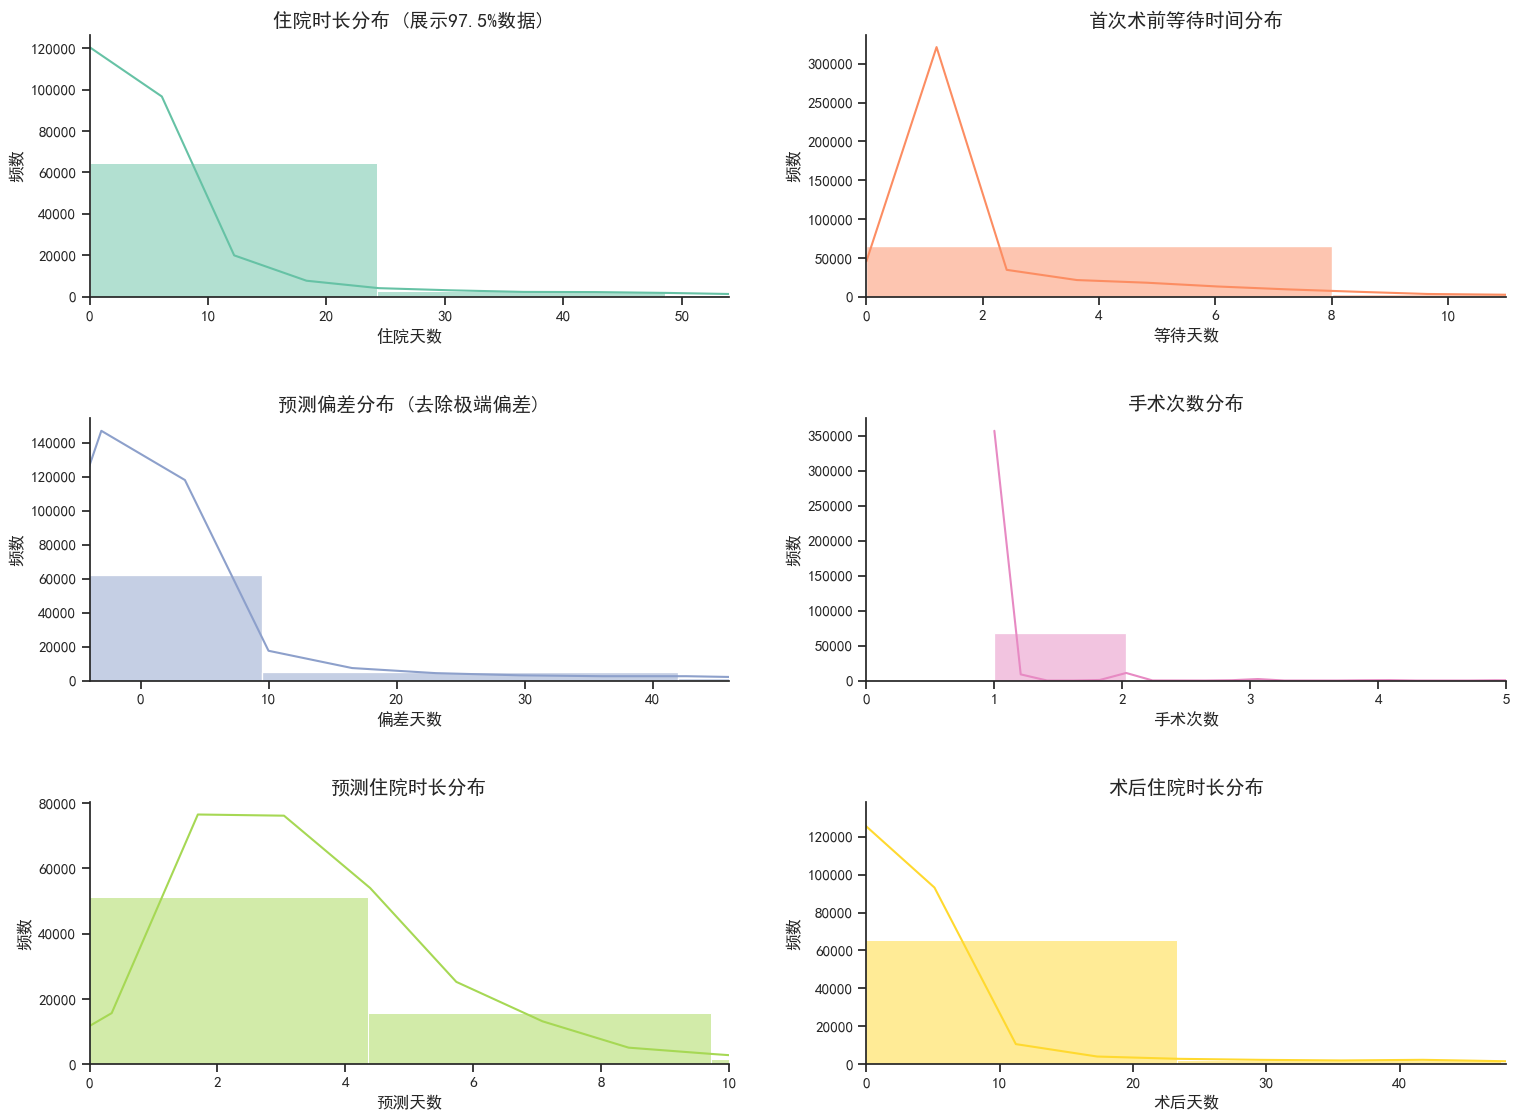

In [49]:
sns.set_style("ticks", {"font.sans-serif": ["SimHei", "Arial Unicode MS"]})
plt.rcParams['axes.unicode_minus'] = False 
plt.figure(figsize=[16, 12])
colors = sns.color_palette("Set2")

# 住院时长 
plt.subplot(321)
sns.histplot(df2['Len_of_Stay'], bins=50, kde=True, color=colors[0])

xmax1 = df2['Len_of_Stay'].quantile(0.975) 
plt.xlim(0, xmax1)
plt.title('住院时长分布 (展示97.5%数据)', fontsize=14, fontweight='bold')
plt.xlabel('住院天数')
plt.ylabel('频数')

# 首次术前等待时间
plt.subplot(322)
sns.histplot(df2['TIME_UNTIL_1ST'], bins=30, kde=True, color=colors[1])
xmax2 = df2['TIME_UNTIL_1ST'].quantile(0.975) 
plt.xlim(0, xmax2)
plt.title('首次术前等待时间分布', fontsize=14, fontweight='bold')
plt.xlabel('等待天数')
plt.ylabel('频数')

# 预测偏差
plt.subplot(323)
# 预测偏差可能有正有负，截断前后各2.5%的极端值
sns.histplot(df2['DIFFERENCE_OF_DISCHARGE'], bins=40, kde=True, color=colors[2])
xmin3 = df2['DIFFERENCE_OF_DISCHARGE'].quantile(0.025)
xmax3 = df2['DIFFERENCE_OF_DISCHARGE'].quantile(0.975)
plt.xlim(xmin3, xmax3)
plt.title('预测偏差分布 (去除极端偏差)', fontsize=14, fontweight='bold')
plt.xlabel('偏差天数')
plt.ylabel('频数')

# 手术次数 
plt.subplot(324)
sns.histplot(df2['NUMBER_OF_SURGERIES'], bins=40, kde=True, color=colors[3])
xmax4 = df2['NUMBER_OF_SURGERIES'].quantile(0.995) 
plt.xlim(0, xmax4)
# X轴显示整数刻度
plt.xticks(range(int(xmax4) + 1))
plt.title('手术次数分布', fontsize=14, fontweight='bold')
plt.xlabel('手术次数')
plt.ylabel('频数')

# 预测住院时长
plt.subplot(325)
sns.histplot(df2['FORECAST_LOS'], bins=50, kde=True, color=colors[4])
xmax5 = df2['FORECAST_LOS'].quantile(0.975)
plt.xlim(0, xmax5)
plt.title('预测住院时长分布', fontsize=14, fontweight='bold')
plt.xlabel('预测天数')
plt.ylabel('频数')

#术后住院时长
plt.subplot(326)
sns.histplot(df2['POST_STAY'], bins=50, kde=True, color=colors[5])
xmax6 = df2['POST_STAY'].quantile(0.975)
plt.xlim(0, xmax6)
plt.title('术后住院时长分布', fontsize=14, fontweight='bold')
plt.xlabel('术后天数')
plt.ylabel('频数')

sns.despine() # 去掉多余边框
plt.tight_layout(pad=3.0) #调整子图间距，防止标题和坐标轴重叠
plt.show()

In [50]:
# Len_of_Stay / TIME_UNTIL_1ST / DIFFERENCE_OF_DISCHARGE / NUMBER_OF_SURGERIES/ FORECAST_LOS / POST_STAY
# 住院时长/等待时间/预测偏差/手术次数/预测时长/术后时长呈现明显的尖峰且右偏分布

#### 可视化各科室住院时长

Text(0.5, 0, '住院时长')

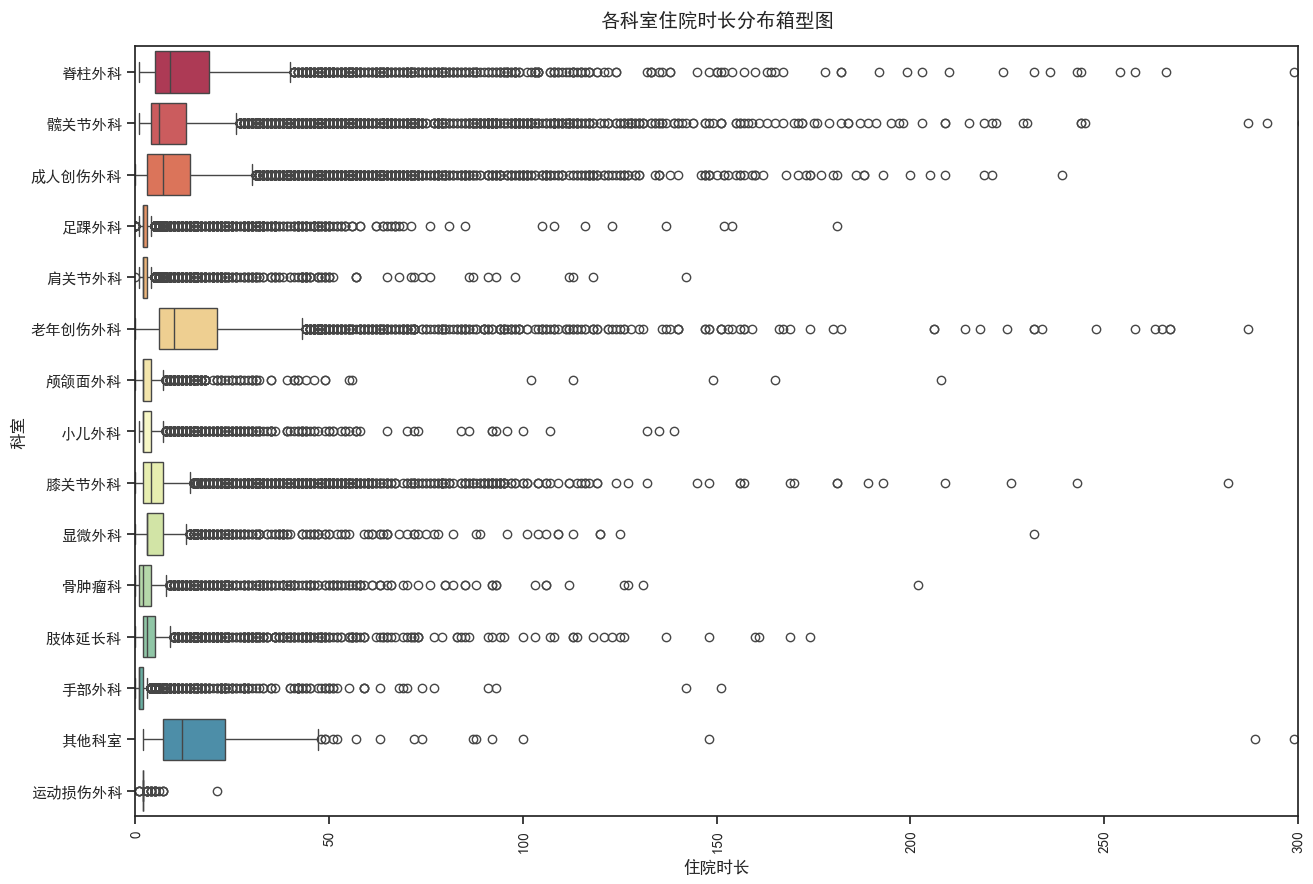

In [51]:
plt.figure(figsize = (15,10))
plt.xticks(rotation = 90)
plt.ylim(0, 250)
plt.xlim(0, 300)
sns.boxplot(
    x=df2['Len_of_Stay'],
    y=df2['科室'],
    hue = df2["SERVICE"],
    palette='Spectral',
    legend=False
)
plt.title(f"各科室住院时长分布箱型图", pad=15, fontsize=14)
plt.ylabel("科室", fontsize=12)
plt.xlabel("住院时长", fontsize=12)

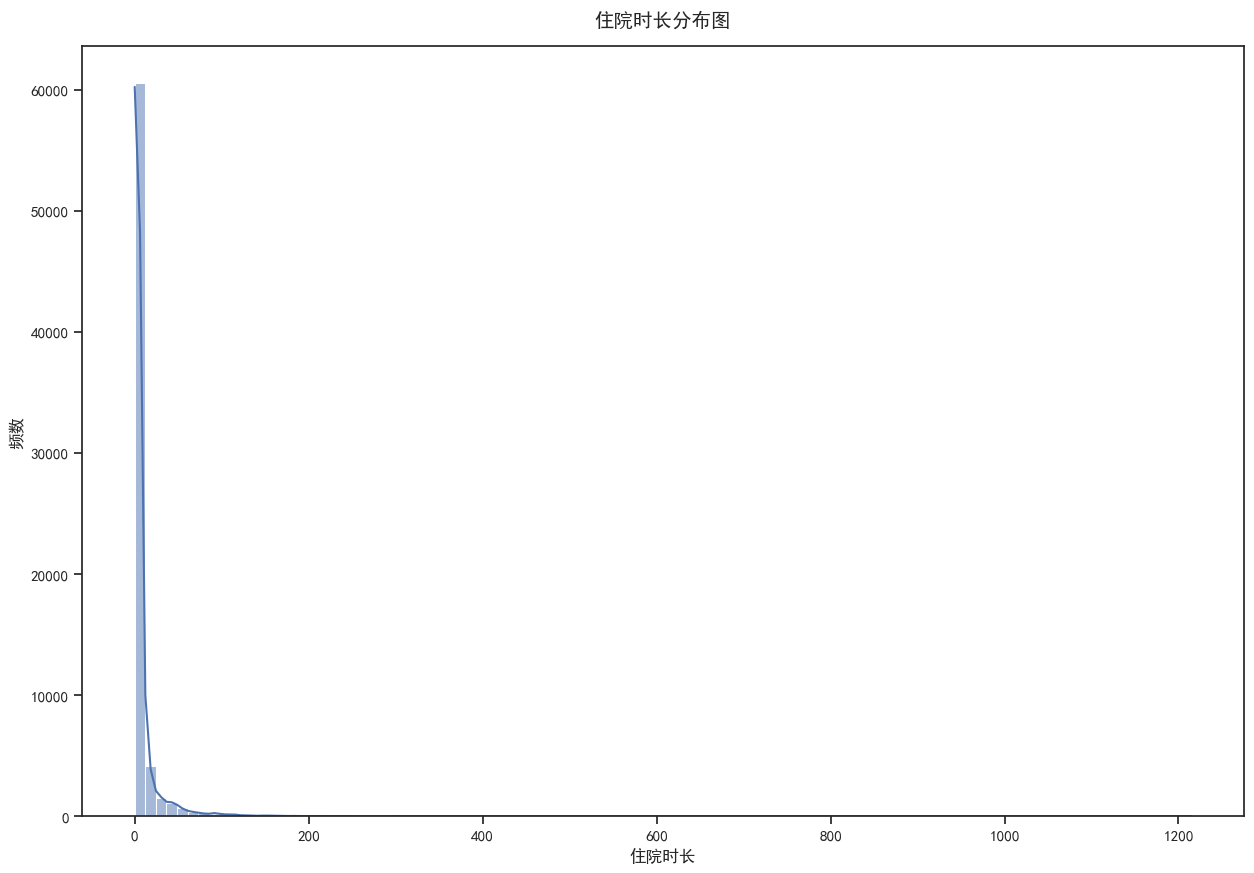

In [52]:
plt.figure(figsize = (15,10))
sns.histplot(df2['Len_of_Stay'], bins=100, kde=True)
plt.title("住院时长分布图", pad=15, fontsize=14)
plt.ylabel("频数", fontsize=12)
plt.xlabel("住院时长", fontsize=12)
plt.show()

In [53]:
df2['Len_of_Stay'].describe(percentiles=[0.9, 0.95, 0.99, 0.999])

count    69426.000000
mean         8.152176
std         19.306709
min          0.000000
50%          3.000000
90%         16.000000
95%         34.000000
99%         92.000000
99.9%      209.000000
max       1215.000000
Name: Len_of_Stay, dtype: float64

##### 去除LOS的异常值/#阈值0.9995

In [54]:
print(len(df2))
#阈值0.9995
LOS = df2.groupby('SERVICE')['Len_of_Stay'].transform(lambda x:x.quantile(0.9995))
df3 = df2[df2['Len_of_Stay'] < LOS].copy()
print(len(df3))

69426
69384


##### 移除“手术次数(NUMBER.OF.SURGERIES)”的异常值 阈值0.9995

In [55]:
df3['NUMBER_OF_SURGERIES'].describe()

count    69384.000000
mean         1.095642
std          0.651606
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         30.000000
Name: NUMBER_OF_SURGERIES, dtype: float64

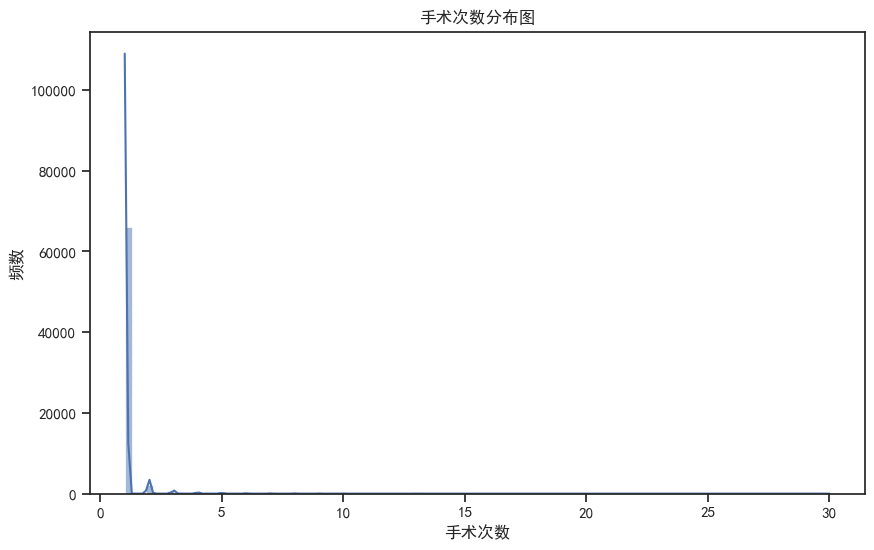

In [56]:
#可视化
plt.figure(figsize=(10, 6))
sns.histplot(df3['NUMBER_OF_SURGERIES'], bins=100, kde=True)
plt.title("手术次数分布图")
plt.xlabel("手术次数")
plt.ylabel("频数")
plt.show()

In [57]:
df3['NUMBER_OF_SURGERIES'].describe(percentiles=[0.9, 0.95, 0.99, 0.999])

count    69384.000000
mean         1.095642
std          0.651606
min          1.000000
50%          1.000000
90%          1.000000
95%          1.000000
99%          3.000000
99.9%       10.000000
max         30.000000
Name: NUMBER_OF_SURGERIES, dtype: float64

In [58]:
print(len(df3))
df4 = df3[df3['NUMBER_OF_SURGERIES'] <= 6].copy()
print(len(df4))

69384
69177


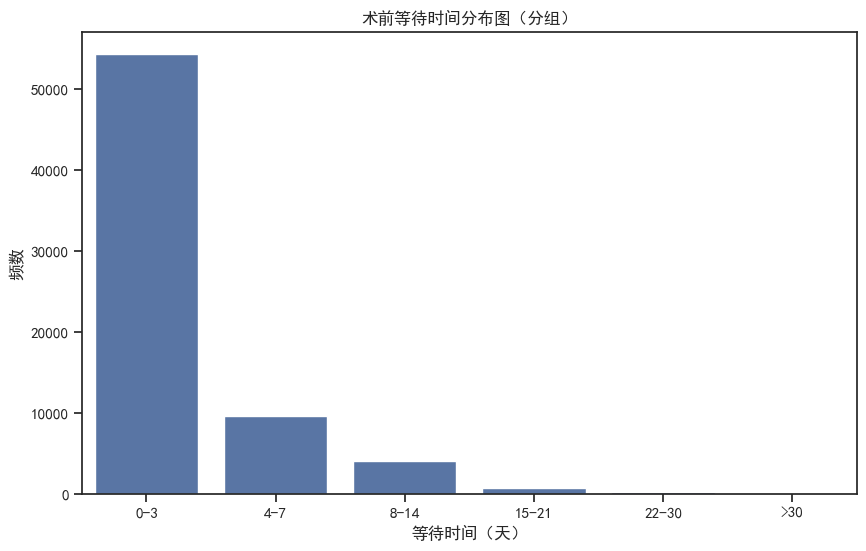

In [59]:
# 创建分组列
bins = [0, 3, 7, 14, 21, 30, 100]
labels = ['0-3', '4-7', '8-14', '15-21', '22-30', '>30']
df4['WAIT_GROUP'] = pd.cut(df4['TIME_UNTIL_1ST'], bins=bins, labels=labels, right=False)

# 画图
plt.figure(figsize=(10,6))
sns.countplot(data=df4, x='WAIT_GROUP', order=labels)
plt.title("术前等待时间分布图（分组）")
plt.xlabel("等待时间（天）")
plt.ylabel("频数")
plt.show()

#### 对出院原因分组

In [60]:
df4['REASON_FOR_DISCHARGE'].unique()

array(['MEDICAL DECISION', 'PATIENT DECISION', 'DEATH',
       'SPEECH THERAPISTS DECISION', 'TRANSFER', 'BY REQUEST',
       'HOSPITALIZATION CANCELED', 'PHYSIOTHERAPY DECISION',
       'COMPLIANCE WITH THE OBJECTIVES OF THE HOME CARE PLAN',
       'REOPERATION'], dtype=object)

In [61]:
df4['REASON_FOR_DISCHARGE'].value_counts()

REASON_FOR_DISCHARGE
MEDICAL DECISION                                        68577
DEATH                                                     309
TRANSFER                                                  137
PATIENT DECISION                                           99
BY REQUEST                                                 40
SPEECH THERAPISTS DECISION                                  5
HOSPITALIZATION CANCELED                                    5
COMPLIANCE WITH THE OBJECTIVES OF THE HOME CARE PLAN        3
PHYSIOTHERAPY DECISION                                      1
REOPERATION                                                 1
Name: count, dtype: int64

In [62]:
category_mapping = {    
# BY REQUEST& PATIENT DECISION：患者/家属意愿 合并为'PATIENT/FAMILY DECISION'    
'PATIENT DECISION': '患者/家属意愿',    
'BY REQUEST': '患者/家属意愿',   
# 将样本量极小的分类合并为其他    
'SPEECH THERAPISTS DECISION': '医疗决策',  #言语治疗师决定  
'COMPLIANCE WITH THE OBJECTIVES OF THE HOME CARE PLAN': '医疗决策',    #符合居家治疗标准
'REOPERATION': '医疗决策',    #二次手术
'PHYSIOTHERAPY DECISION': '医疗决策',    #物理治疗师决定
'HOSPITALIZATION CANCELED': '医疗决策', #取消入院,
'MEDICAL DECISION': '医疗决策',
'DEATH': '死亡',
'TRANSFER': '转院'
}
df4['REASON_GROUPED'] = df1['REASON_FOR_DISCHARGE'].replace(category_mapping)
print(df4['REASON_GROUPED'].value_counts())   

REASON_GROUPED
医疗决策       68592
死亡           309
患者/家属意愿      139
转院           137
Name: count, dtype: int64


#### 对转院地点分组

In [63]:
df4.groupby(['SERVICE','TRANSFER_PLACE'])['Len_of_Stay'].describe()

count  \
SERVICE      TRANSFER_PLACE                                              
ADULT TRAUMA                                                ...   31.0   
             ABRIGO JOSE SARAMANGO                          ...    1.0   
             ASSOC. HOSP. DE CAMBUCI                        ...    2.0   
             ASSOC. HOSP.SAO SEBASTIAO ALTO                 ...    7.0   
             ASSOC.CAR.HOSP.-NOVA IGUACU                    ...    1.0   
...                                                                ...   
SPINE        inativo -SUS - SAO PEDRO DA ALDEIA             ...    1.0   
             inativo -SUS DE MARICA                         ...    1.0   
             inativo -SUS DE RIO DAS OSTRAS                 ...    1.0   
             inativo -URMED - URGENCIAS MEDICAS             ...    1.0   
SPORT TRAUMA HOME                                                176.0   

                                                                      mean  \
SERVICE      TRANSFER_PLACE                                                  
ADULT TRAUMA                                                ...  10.967742   
             ABRIGO JOSE SARAMANGO                          ...  21.000000   
             ASSOC. HOSP. DE CAMBUCI                        ...   9.500000   
             ASSOC. HOSP.SAO SEBASTIAO ALTO                 ...  16.142857   
             ASSOC.CAR.HOSP.-NOVA IGUACU                    ...   2.000000   
...                                                                    ...   
SPINE        inativo -SUS - SAO PEDRO DA ALDEIA             ...  14.000000   
             inativo -SUS DE MARICA                         ...  10.000000   
             inativo -SUS DE RIO DAS OSTRAS                 ...  39.000000   
             inativo -URMED - URGENCIAS MEDICAS             ...   6.000000   
SPORT TRAUMA HOME                                                 2.289773   

                                                                       std  \
SERVICE      TRANSFER_PLACE                                                  
ADULT TRAUMA                                                ...  11.998566   
             ABRIGO JOSE SARAMANGO                          ...        NaN   
             ASSOC. HOSP. DE CAMBUCI                        ...   7.778175   
             ASSOC. HOSP.SAO SEBASTIAO ALTO                 ...  16.737469   
             ASSOC.CAR.HOSP.-NOVA IGUACU                    ...        NaN   
...                                                                    ...   
SPINE        inativo -SUS - SAO PEDRO DA ALDEIA             ...        NaN   
             inativo -SUS DE MARICA                         ...        NaN   
             inativo -SUS DE RIO DAS OSTRAS                 ...        NaN   
             inativo -URMED - URGENCIAS MEDICAS             ...        NaN   
SPORT TRAUMA HOME                                                 0.962798   

                                                                  min    25%  \
SERVICE      TRANSFER_PLACE                                                    
ADULT TRAUMA                                                ...   1.0   2.50   
             ABRIGO JOSE SARAMANGO                          ...  21.0  21.00   
             ASSOC. HOSP. DE CAMBUCI                        ...   4.0   6.75   
             ASSOC. HOSP.SAO SEBASTIAO ALTO                 ...   6.0   8.00   
             ASSOC.CAR.HOSP.-NOVA IGUACU                    ...   2.0   2.00   
...                                                               ...    ...   
SPINE        inativo -SUS - SAO PEDRO DA ALDEIA             ...  14.0  14.00   
             inativo -SUS DE MARICA                         ...  10.0  10.00   
             inativo -SUS DE RIO DAS OSTRAS                 ...  39.0  39.00   
             inativo -URMED - URGENCIAS MEDICAS             ...   6.0   6.00   
SPORT TRAUMA HOME                                                 1.0   2.00   

                               

In [64]:
df4['TRANSFER_PLACE'].value_counts()

TRANSFER_PLACE
HOME                                                      60881
HOSPITAL DA POSSE                                          1084
HOSP. MUNICIPAL SOUZA AGUIAR                                580
                                                            364
HOSPITAL EST. ALBERTO TORRES                                357
                                                          ...  
inativo -SUS - OLARIA                                         1
HOSP UNIVER SUL FLUMINENSE                                    1
HOSPITAL CORONEL MOTTA                                        1
H M JAPERI                                                    1
inativo -POLICL RONALDO GAZOLLA - PSF                         1
Name: count, Length: 357, dtype: int64

In [65]:
#替换空值
df4['TRANSFER_PLACE'] = df4['TRANSFER_PLACE'].fillna('未知/缺失').astype(str).str.strip().replace('', '未知/缺失')
#分组
valid_places = df4[(df4['TRANSFER_PLACE'] != 'HOME') & (df4['TRANSFER_PLACE'] != '未知/缺失')]
top_5_hospitals = valid_places['TRANSFER_PLACE'].value_counts().nlargest(5).index.tolist()

def clean_transfer_place(place):
    if place == 'HOME':
        return '回家'
    elif place in top_5_hospitals:
        return place
    else:
        return '其他医院'
        
transfer_mapping ={
    '回家': '回家',
    '其他医院': '其他医院',
    'HOSPITAL DA POSSE': 'POSSE医院',
    'HOSP. MUNICIPAL SOUZA AGUIAR': 'SOUZA医院',
    'HOSPITAL EST. ALBERTO TORRES': 'TORRES医院',
    'H.EST.ADAO PEREIRA NUNES': 'NUNES医院',
    'HOSP.MUN.CONDE MODESTO LEAL': 'LEAL医院'
}
df4['转院地点'] = df4['TRANSFER_PLACE'].apply(clean_transfer_place).replace(transfer_mapping)
print(df4['转院地点'].value_counts())

转院地点
回家          60881
其他医院         5634
POSSE医院      1084
SOUZA医院       580
TORRES医院      357
NUNES医院       334
LEAL医院        307
Name: count, dtype: int64


#### 对ICD疾病分组

In [66]:
df4['Type_final'].unique()

<StringArray>
[          'Neoplasm of uncertain behavior of other and unspecified sites',
                                    'Broken internal right hip prosthesis',
                                       'Stress fracture, unspecified site',
                                                    'Aneurysmal bone cyst',
                                                          'Unmapped/Other',
                      'Unspecified fracture of upper end of right humerus',
    'Unspecified rotator cuff tear or rupture, not specified as traumatic',
                                   'Unspecified fracture of right patella',
                                         'Subluxation complex (vertebral)',
 'Infection and inflammatory reaction due to peritoneal dialysis catheter',
 ...
       'Complete traumatic amputation at level between right hip and knee',
                                  'Osteitis deformans of unspecified bone',
 'Unspecified injury of adductor muscle, fascia and tendon of right t

In [67]:
df4['Type_final'].value_counts()

Type_final
Unmapped/Other                                                       5280
Unilateral primary osteoarthritis of knee                            4086
Other mononeuropathies                                               2282
Osteoarthritis of hip, unspecified                                   2103
Carpal tunnel syndrome                                               2000
                                                                     ... 
Benign neoplasm of respiratory system, unspecified                      1
Vascular myelopathies                                                   1
Traumatic spondylopathy                                                 1
Other noninfective disorders of lymphatic vessels and lymph nodes       1
Traumatic rupture of lumbar intervertebral disc                         1
Name: count, Length: 1066, dtype: Int64

In [68]:
#由于疾病最终类型种类复杂且没有明确分类依据，所以根据国际ICD编码疾病分类映射

df4['ICD_letter'] = df4['ICD'].str.upper().str.replace(r"[^A-Z]", "", regex=True).str[0]
icd10_full_dict = {    
'A': 'A-B: Infectious',    #A-B：传染性疾病
'B': 'A-B: Infectious',    
'C': 'C-D: Neoplasms',    #C：肿瘤
'D': 'C-D: Neoplasms/Blood',    #D：肿瘤及血液系统疾病
'E': 'E: Endocrine',    #E：内分泌、营养及代谢疾病
'F': 'F: Mental',    #M: 精神与行为障碍
'G': 'G: Nervous',    #G 神经系统疾病
'H': 'H: Eye/Ear',    #E 眼及耳相关疾病
'I': 'I: Circulatory',    #I 循环系统疾病
'J': 'J: Respiratory',    #J 呼吸系统疾病
'K': 'K: Digestive',    #K 消化系统疾病
'L': 'L: Skin',    #L 皮肤及皮下组织疾病
'M': 'M: Musculoskeletal',    #M 肌肉骨骼系统及结缔组织疾病
'N': 'N: Genitourinary',    #N泌尿生殖系统疾病
'O': 'O: Pregnancy',    #O 妊娠、分娩及产褥期相关
'P': 'P: Perinatal',    #P 起源于围生期的疾病
'Q': 'Q: Congenital',    #Q 先天性畸形、变形及染色体异常
'R': 'R: Symptoms',    #R症状、体征及异常临床发现
'S': 'S-T: Trauma',    #S-T 损伤、中毒及外因后果
'T': 'S-T: Trauma',    
'V': 'V-Y: External causes',    #V-Y 外因（交通事故、环境因素等
'W': 'V-Y: External causes',    
'X': 'V-Y: External causes',    
'Y': 'V-Y: External causes',    
'Z': 'Z: Health status factors',    #Z 影响健康状态和与医疗接触的因素
'U': 'U: Special purposes' #U 特殊用途编码
}
df4['ICD_Full_Class'] = df4['ICD_letter'].map(icd10_full_dict).fillna('Unknown (缺失/异常)')
full_class_counts = df4['ICD_Full_Class'].value_counts()
print(full_class_counts)

ICD_Full_Class
M: Musculoskeletal      29938
S-T: Trauma             23392
G: Nervous               5230
Q: Congenital            3746
C-D: Neoplasms/Blood     3234
                        ...  
E: Endocrine               15
J: Respiratory             10
N: Genitourinary            7
F: Mental                   6
O: Pregnancy                1
Name: count, Length: 21, dtype: int64


#### 保留样本量 > 1000 的核心类别

In [69]:
core_classes = [    
'M: Musculoskeletal',    
'S-T: Trauma',    
'G: Nervous',    
'Q: Congenital',    
'C-D: Neoplasms/Blood',    
'C-D: Neoplasms'
]
df4['ICD_Final_Group'] = np.where(df4['ICD_Full_Class'].isin(core_classes),
                                  df4['ICD_Full_Class'],                                  
'Other')
df4['ICD_Final_Group'] = df4['ICD_Final_Group'].replace({
'M: Musculoskeletal': '骨骼肌肉系统疾病',
'S-T: Trauma'  :  '创伤与损伤',
'G: Nervous':  '神经系统疾病',
'Q: Congenital':  '先天性异常',
'C-D: Neoplasms/Blood':'肿瘤及血液系统疾病',    
'C-D: Neoplasms': '肿瘤及血液系统疾病',
'Other':'其他'
})
df4['ICD_Final_Group'].value_counts()

ICD_Final_Group
骨骼肌肉系统疾病     29938
创伤与损伤        23392
神经系统疾病        5230
肿瘤及血液系统疾病     4275
先天性异常         3746
其他            2596
Name: count, dtype: int64

In [70]:
df4.groupby('ICD_Final_Group')['Len_of_Stay'].describe()

,count,mean,std,min,25%,50%,75%,max
ICD_Final_Group,,,,,,,,
先天性异常,3746.0,4.298719,10.095839,0.0,2.0,2.0,3.0,354.0
其他,2596.0,9.600924,18.821938,0.0,2.0,3.0,8.0,258.0
创伤与损伤,23392.0,10.899624,19.533255,0.0,2.0,4.0,10.0,328.0
神经系统疾病,5230.0,1.700574,5.640588,0.0,1.0,1.0,2.0,182.0
肿瘤及血液系统疾病,4275.0,4.123743,8.651977,0.0,1.0,2.0,3.0,182.0
骨骼肌肉系统疾病,29938.0,6.856270,13.320301,0.0,2.0,3.0,6.0,428.0


### 3. 单因素检验

#### 住院时长

In [71]:
# 计算统计指标
Service_stats = df4.groupby('科室')['POST_STAY'].agg(['mean', 'median', 'count', 'std'])
Service_stats = Service_stats.add_prefix('POS_')
Service_stats = Service_stats.sort_values(by='POS_mean', ascending=False)
Service_stats

,POS_mean,POS_median,POS_count,POS_std
科室,,,,
其他科室,19.008621,7.0,116,38.180918
脊柱外科,14.488976,6.0,2812,25.590602
老年创伤外科,12.257429,4.0,2793,22.748201
髋关节外科,11.183436,4.0,7474,22.364885
成人创伤外科,9.274642,2.0,6838,18.493907
显微外科,5.504227,2.0,1656,11.276315
膝关节外科,5.100691,3.0,10994,10.649300
肢体延长科,4.932621,1.0,2434,12.585865
骨肿瘤科,3.269930,1.0,3412,8.588075


In [72]:
df4['科室'].value_counts()

科室
手部外科      11962
膝关节外科     10994
髋关节外科      7474
足踝外科       7308
成人创伤外科     6838
肩关节外科      4703
小儿外科       3822
骨肿瘤科       3412
脊柱外科       2812
老年创伤外科     2793
颅颌面外科      2677
肢体延长科      2434
显微外科       1656
运动损伤外科      176
其他科室        116
Name: count, dtype: int64

Text(0.5, 0, '住院时长')

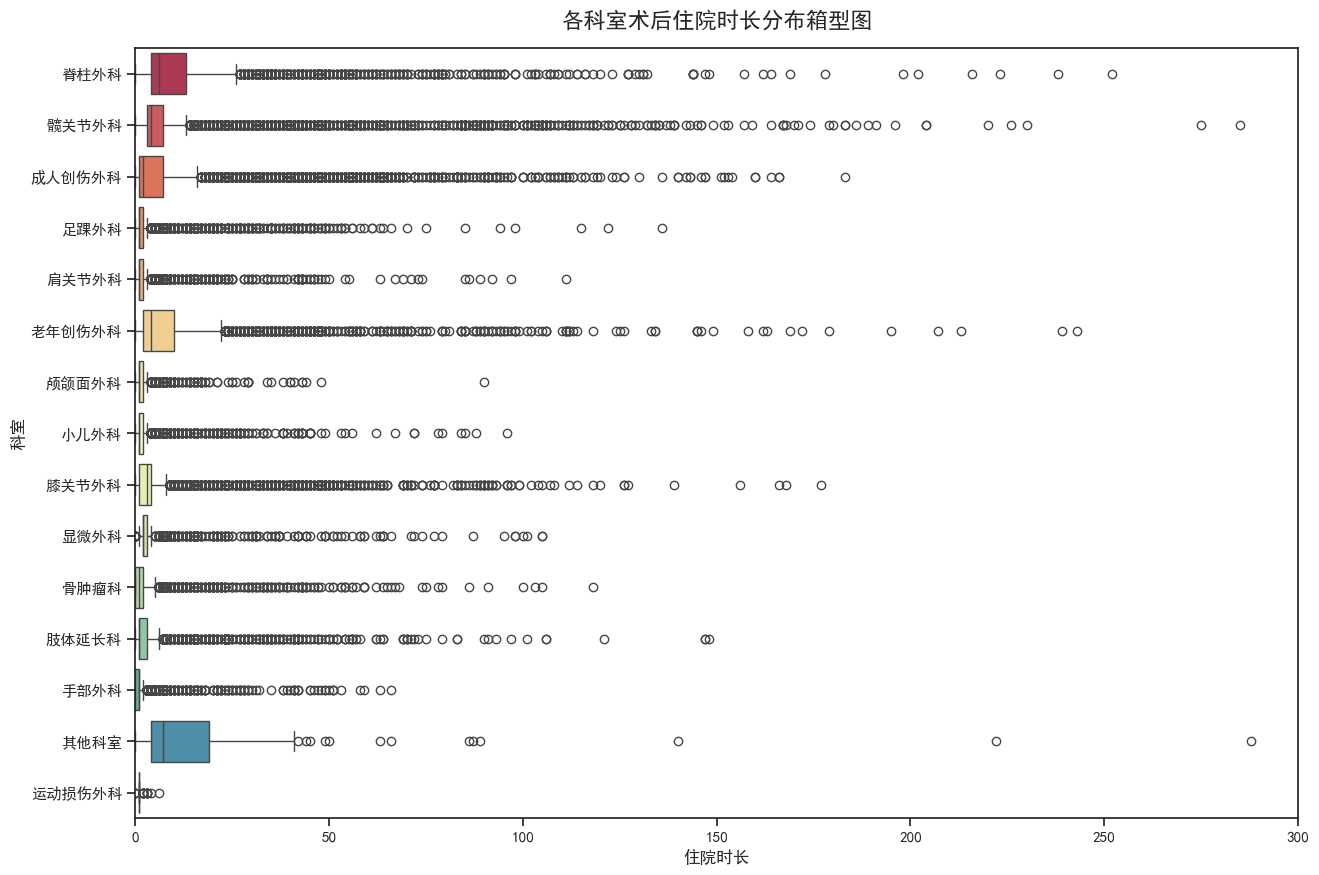

In [73]:
plt.figure(figsize = (15,10))
plt.ylim(0, 250)
plt.xlim(0, 300)
sns.boxplot( x=df4['POST_STAY'], y=df4['科室'], hue = df4['科室'], palette='Spectral', legend=False)
plt.title("各科室术后住院时长分布箱型图", pad=15, fontsize=16)
plt.xlabel("住院时长", fontsize=12) 

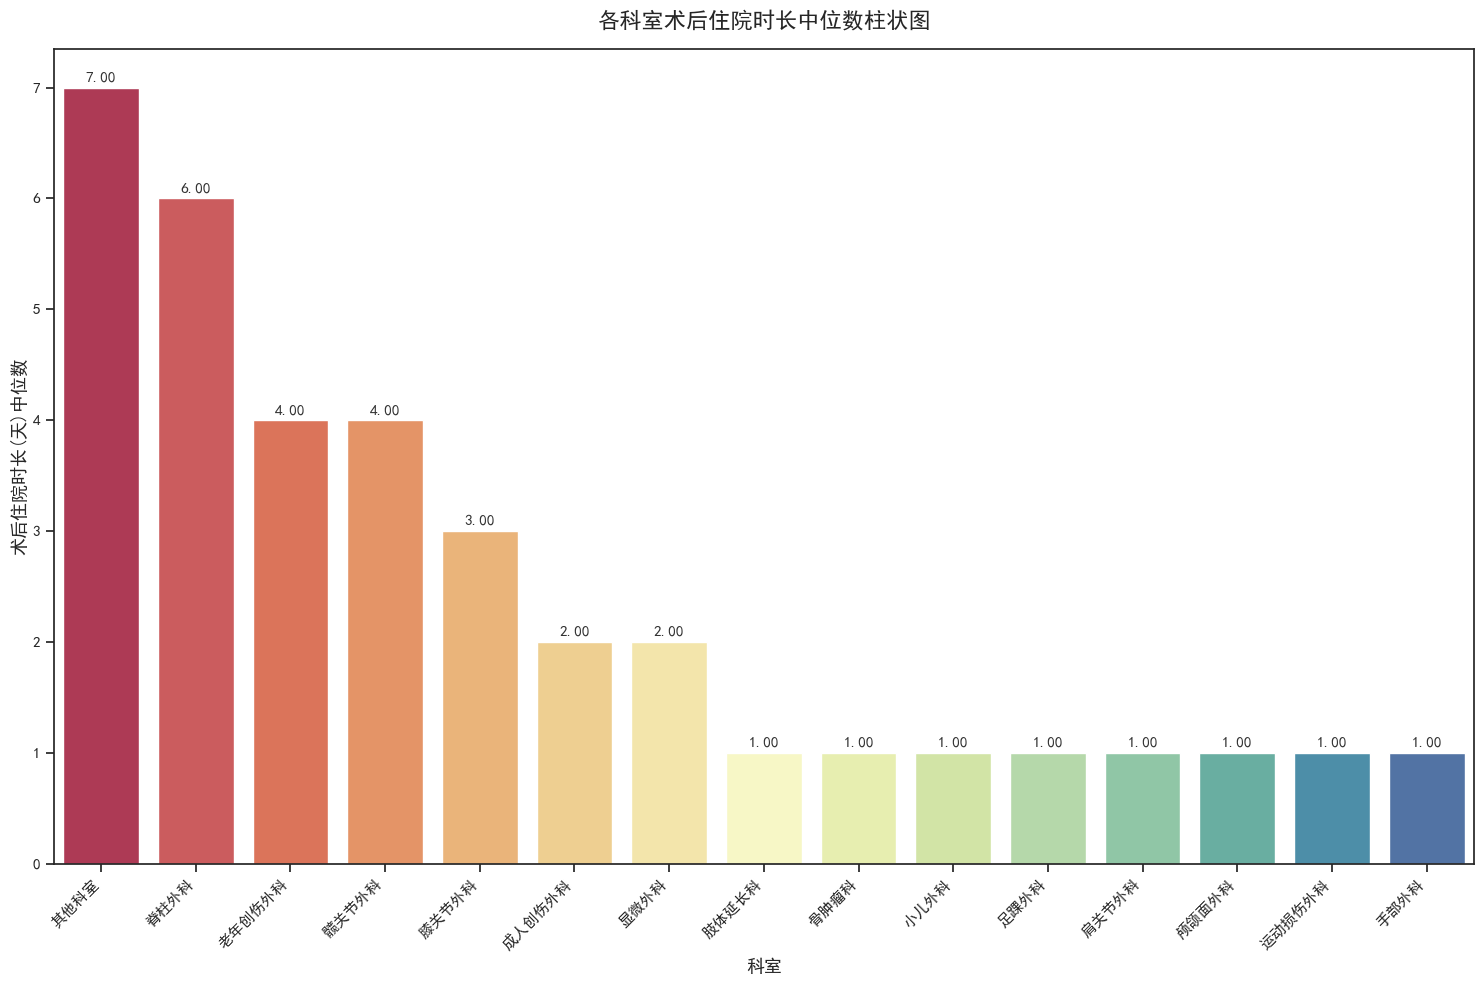

In [74]:
stats_sorted = Service_stats.sort_values(by='POS_median', ascending=False)
plt.figure(figsize=(15, 10))
ax = sns.barplot( x=stats_sorted.index, y=stats_sorted['POS_median'], hue=stats_sorted.index, palette='Spectral')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=11, color='#333333')
    
plt.xticks(rotation=45, ha='right')
plt.title("各科室术后住院时长中位数柱状图", pad=15, fontsize=16)
plt.ylabel("术后住院时长(天)中位数", fontsize=13)  
plt.xlabel("科室", fontsize=13)    
plt.tight_layout()
plt.show()

H检验

In [75]:
from scipy.stats import kruskal

In [76]:
data_groups = []
service_list = df4['科室'].unique()
for i in service_list:
    group = df4[df4['科室'] == i]['POST_STAY']
    data_groups.append(group)
h_statistic, p_value = kruskal(*data_groups)
print(f"H-statistic: {h_statistic:.4f}")
print(f"P-value: {p_value:.4f}")
alpha = 0.05  #显著性水平5%
if p_value < alpha:    
    print(f"P值 ({p_value:.4f}) 小于 {alpha}，拒绝原假设")
else:    
    print(f"P值 ({p_vlaue:.4f}) 大于或等于 {alpha}，无法拒绝原假设")

H-statistic: 27118.3355
P-value: 0.0000
P值 (0.0000) 小于 0.05，拒绝原假设


In [77]:
numeric_columns = df4.select_dtypes(include=[np.number]).columns
print(df4[numeric_columns].isnull().sum()) # nan的数量
print(np.isinf(df4[numeric_columns]).sum()) # inf的数量

AGE                        0
NUMBER_OF_SURGERIES        0
COMORBIDITIES              0
Len_of_Stay                0
TIME_UNTIL_1ST             0
FORECAST_LOS               0
DIFFERENCE_OF_DISCHARGE    0
POST_STAY                  0
SEX_encoded                0
dtype: int64
AGE                        0
NUMBER_OF_SURGERIES        0
COMORBIDITIES              0
Len_of_Stay                0
TIME_UNTIL_1ST             0
FORECAST_LOS               0
DIFFERENCE_OF_DISCHARGE    0
POST_STAY                  0
SEX_encoded                0
dtype: int64


#### 计算各变量和住院时长的皮尔森相关系数

In [78]:
df4.corr(numeric_only=True)['POST_STAY']

AGE                        0.090014
NUMBER_OF_SURGERIES        0.647833
COMORBIDITIES              0.013611
Len_of_Stay                0.973116
TIME_UNTIL_1ST             0.289460
FORECAST_LOS               0.322657
DIFFERENCE_OF_DISCHARGE    0.907167
POST_STAY                  1.000000
SEX_encoded                0.022258
Name: POST_STAY, dtype: float64

#### 计算住院时长占比

In [79]:
los_sorted = df4['Len_of_Stay'].dropna().sort_values(ascending=False).values
total_patients = len(los_sorted)
total_days = np.sum(los_sorted)

# 累计住院天数
cumulative_days = np.cumsum(los_sorted)

print(f"全院样本量: {total_patients} 人")
print(f"全院累计消耗床位日: {total_days:.0f} 天\n")
print("-" * 40)

# 定义患者比例
percentages = [0.10, 0.20, 0.30] 

for p in percentages:
    # 算出前百分之几的患者对应多少人
    cutoff_idx = int(total_patients * p) 
    
    # 这部分人累计消耗了多少天数 (因为索引从0开始，所以减1)
    consumed_days = cumulative_days[cutoff_idx - 1] 
    
    # 计算天数占比
    consumed_ratio = (consumed_days / total_days) * 100
    
    print(f"全院Top{p*100:.0f}%的住院患者（约 {cutoff_idx} 人）")
    print(f"消耗了全院 {consumed_ratio:.1f}% 的总住院天数")
    print("-" * 40)

全院样本量: 69177 人
全院累计消耗床位日: 527777 天

----------------------------------------
全院Top10%的住院患者（约 6917 人）
消耗了全院 54.8% 的总住院天数
----------------------------------------
全院Top20%的住院患者（约 13835 人）
消耗了全院 69.0% 的总住院天数
----------------------------------------
全院Top30%的住院患者（约 20753 人）
消耗了全院 77.7% 的总住院天数
----------------------------------------


#### 性别

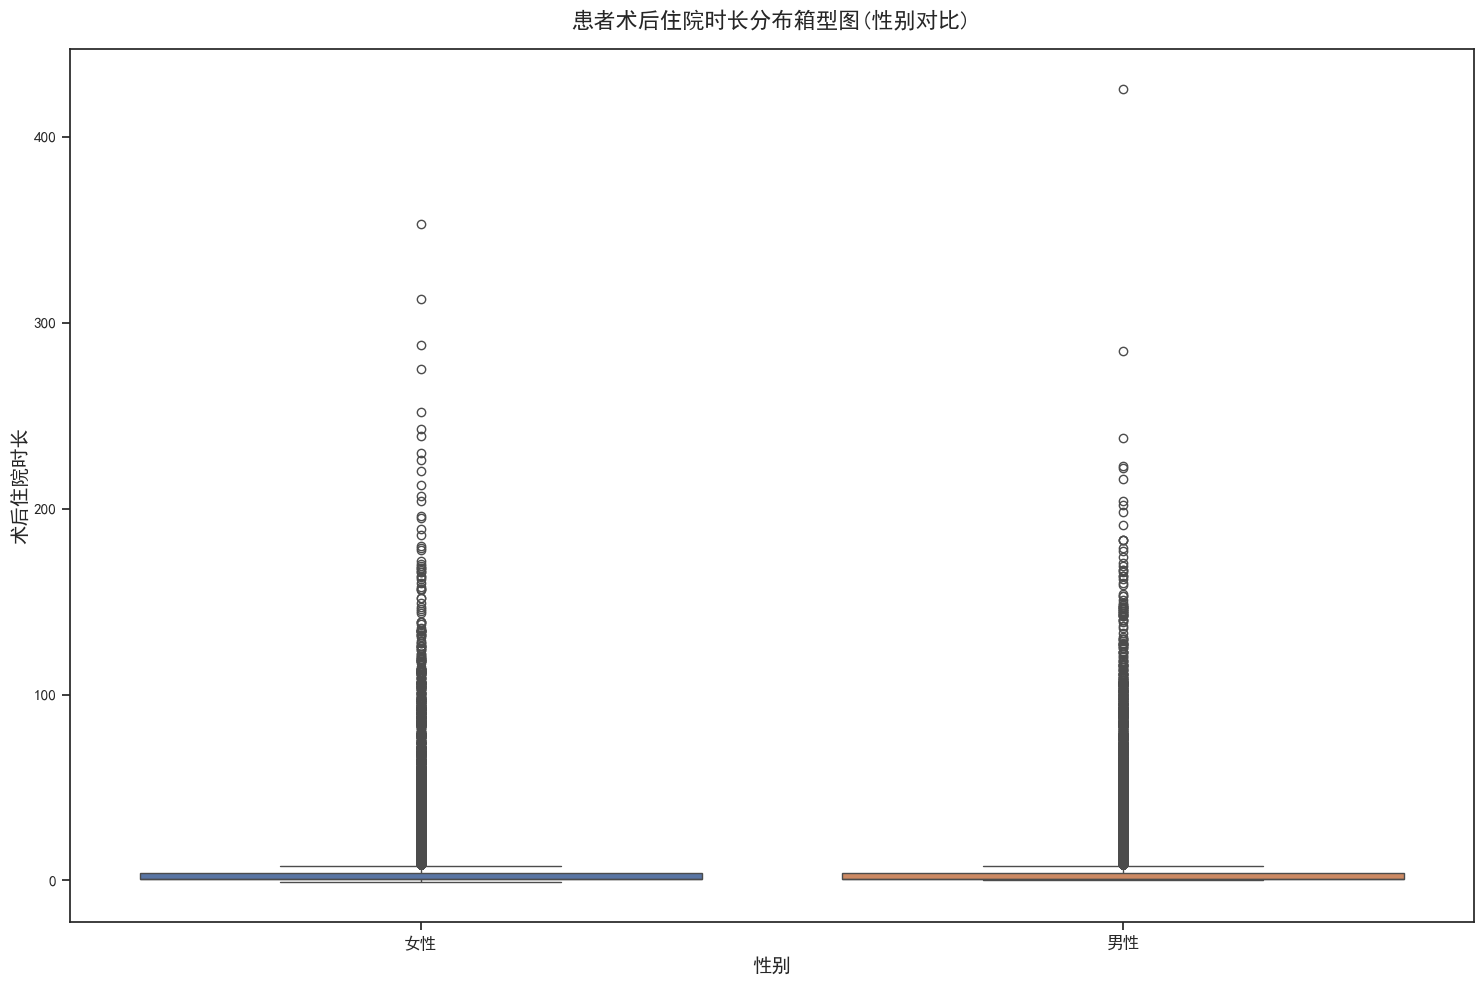

In [80]:
# 映签射性别标
df4['性别'] = df4['SEX_encoded'].map({0: '女性', 1: '男性'})
plt.figure(figsize = (15,10))

plt.xticks(fontsize=12)
sns.boxplot(x = '性别', 
            y = 'POST_STAY', 
            data=df4, 
            hue='SEX_encoded', 
            legend=False)
plt.title("患者术后住院时长分布箱型图(性别对比)",pad=15, fontsize=16)
plt.ylabel("术后住院时长", fontsize=14)  
plt.xlabel("性别", fontsize=14)    
plt.tight_layout()
plt.show()

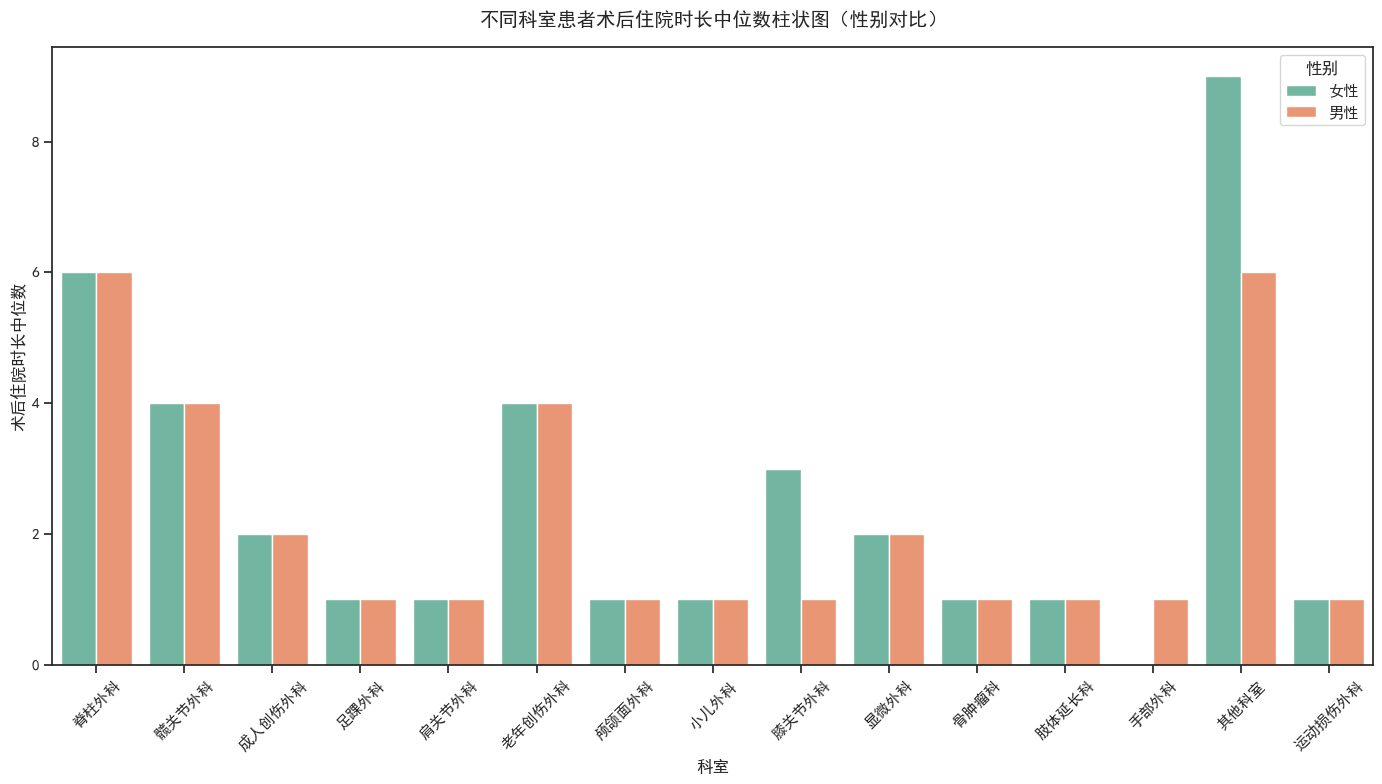

In [81]:
plt.figure(figsize=(14, 8))
sns.barplot(
    x='科室', 
    y='POST_STAY', 
    hue='性别',
    data=df4, 
    errorbar=None, 
    palette='Set2',
    estimator=np.median  #计算中位数
)
plt.xticks(rotation=45)
plt.title("不同科室患者术后住院时长中位数柱状图（性别对比）", fontsize=14, pad=15)
plt.ylabel("术后住院时长中位数", fontsize=12)
plt.xlabel("科室", fontsize=12)
plt.tight_layout()
plt.show()

* U检验

In [82]:
from scipy.stats import mannwhitneyu

group_0 = df4[df4['SEX_encoded'] == 0]['POST_STAY'] 
group_1 = df4[df4['SEX_encoded'] == 1]['POST_STAY']  

if len(group_0) >= 5 and len(group_1) >= 5:        
#U检验
        U_stat, p_value = mannwhitneyu(group_1, group_0, alternative='two-sided')  

print(f"U-statistic: {U_stat:.4f}")
print(f"P-value: {p_value:.4f}")
alpha = 0.05  #显著性水平5%
if p_value < alpha:        
    print(f"P值 ({p_value:.4f}) 小于 {alpha}，拒绝原假设：即不同性别的术后住院时长分布是不同的")
else:        
    print(f"P值 ({p_vlaue:.4f}) 大于或等于 {alpha}，无法拒绝原假设")

U-statistic: 622664109.5000
P-value: 0.0000
P值 (0.0000) 小于 0.05，拒绝原假设：即不同性别的术后住院时长分布是不同的


In [83]:
services = df4['科室'].dropna().unique() 
u_test_results = [] #空列表
for i in services:
    subset = df4[df4['科室'] == i]
    group_0 = subset[subset['SEX_encoded'] == 0]['POST_STAY']
    group_1 = subset[subset['SEX_encoded'] == 1]['POST_STAY']
    
    # 检查样本量
    n0, n1 = len(group_0), len(group_1)
    
    if n0 >= 5 and n1 >= 5:
        stat, p_value = mannwhitneyu(group_1, group_0, alternative='two-sided')
        u_test_results.append({
            'SERVICE': i,
            'N_SEX0': n0,
            'N_SEX1': n1,
            'Median_POS_SEX0': round(group_0.median(), 2),
            'Median_POS_SEX1': round(group_1.median(), 2),
            'P_Value': round(p_value, 4),
            'Significant': '显著' if p_value < 0.05 else '不显著'
        })
    else:
        print(f"跳过科室 {i}: 组0样本={n0}, 组1样本={n1}")

In [84]:
#P值按照从小到大排序
df_u_test = pd.DataFrame(u_test_results)
df_u_test = df_u_test.sort_values(by='P_Value', ascending=True).reset_index(drop=True)
df_u_test

,SERVICE,N_SEX0,N_SEX1,Median_POS_SEX0,Median_POS_SEX1,P_Value,Significant
0,髋关节外科,3413,4061,4.0,4.0,0.0000,显著
1,成人创伤外科,1863,4975,2.0,2.0,0.0000,显著
2,足踝外科,3979,3329,1.0,1.0,0.0000,显著
3,肩关节外科,2224,2479,1.0,1.0,0.0000,显著
4,膝关节外科,5781,5213,3.0,1.0,0.0000,显著
5,显微外科,507,1149,2.0,2.0,0.0000,显著
6,手部外科,7073,4889,0.0,1.0,0.0000,显著
7,小儿外科,1671,2151,1.0,1.0,0.0006,显著
8,其他科室,51,65,9.0,6.0,0.0293,显著
9,颅颌面外科,1154,1523,1.0,1.0,0.0519,不显著


In [85]:
#df4.drop(columns=['SEX_label'])

#### 合并症

In [86]:
df4.groupby(['COMORBIDITIES'])['POST_STAY'].describe()

,count,mean,std,min,25%,50%,75%,max
COMORBIDITIES,,,,,,,,
0,34107.0,5.153869,13.776773,0.0,1.0,1.0,3.0,353.0
1,35070.0,5.534645,14.186212,-1.0,1.0,2.0,4.0,426.0


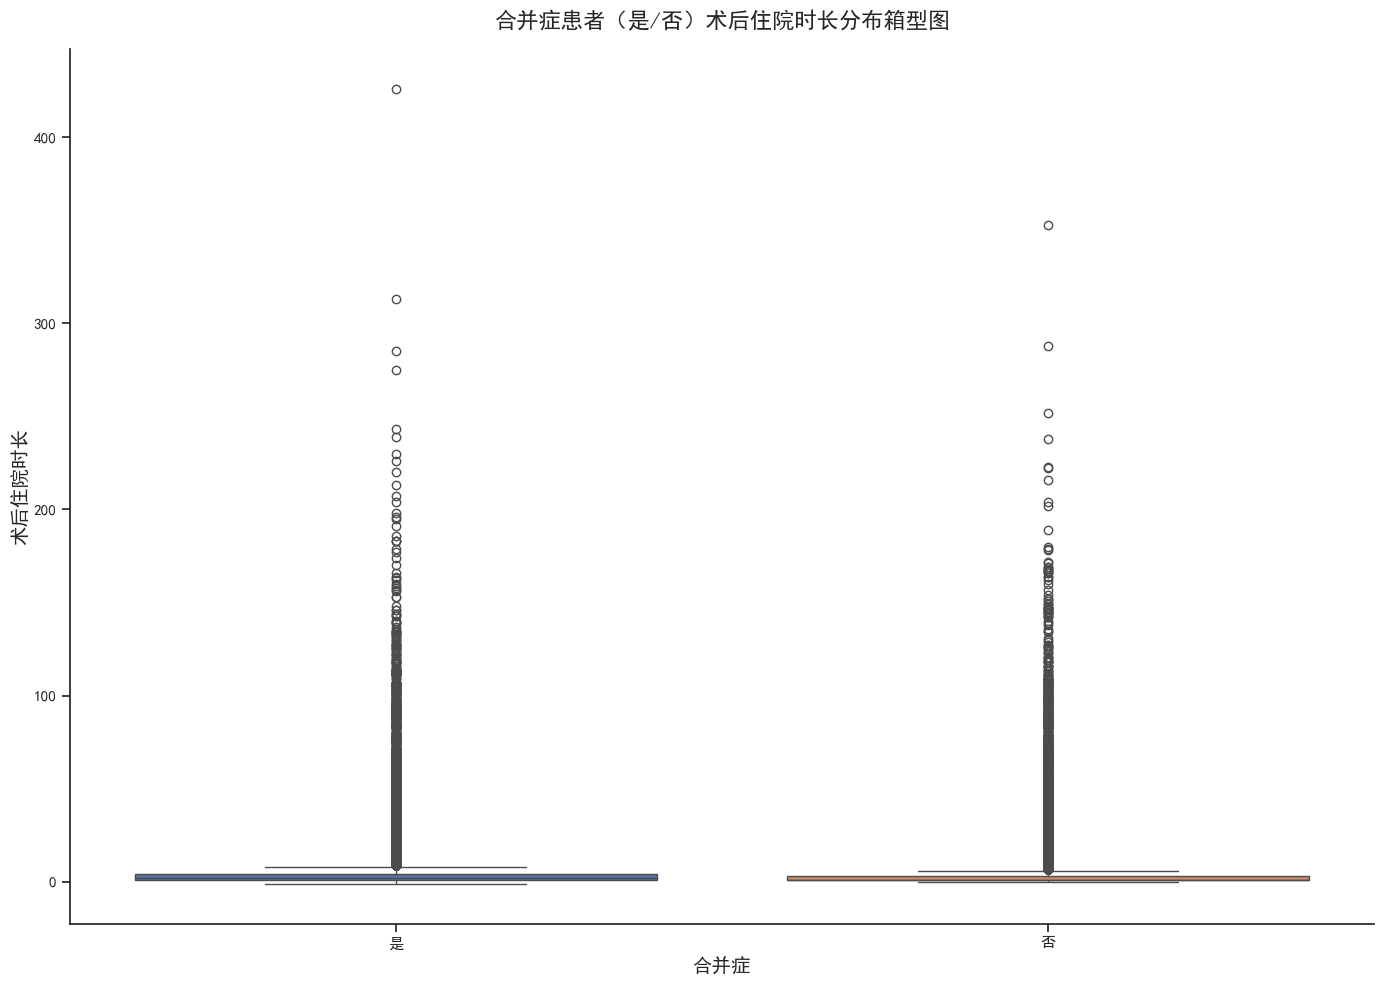

In [87]:
# 映射标签
df4['合并症'] = df4['COMORBIDITIES'].map({0: '否', 1: '是'})

plt.figure(figsize = (14, 10)) 
plt.xticks(rotation = 0)     
sns.boxplot(
    x='合并症', 
    y='POST_STAY',   
    hue='合并症', 
    data=df4,
    legend=False       
)

plt.title("合并症患者（是/否）术后住院时长分布箱型图", fontsize=16, pad=15, fontweight='bold')
plt.ylabel("术后住院时长", fontsize=14)
plt.xlabel("合并症", fontsize=14)
sns.despine()
plt.tight_layout()
plt.show()

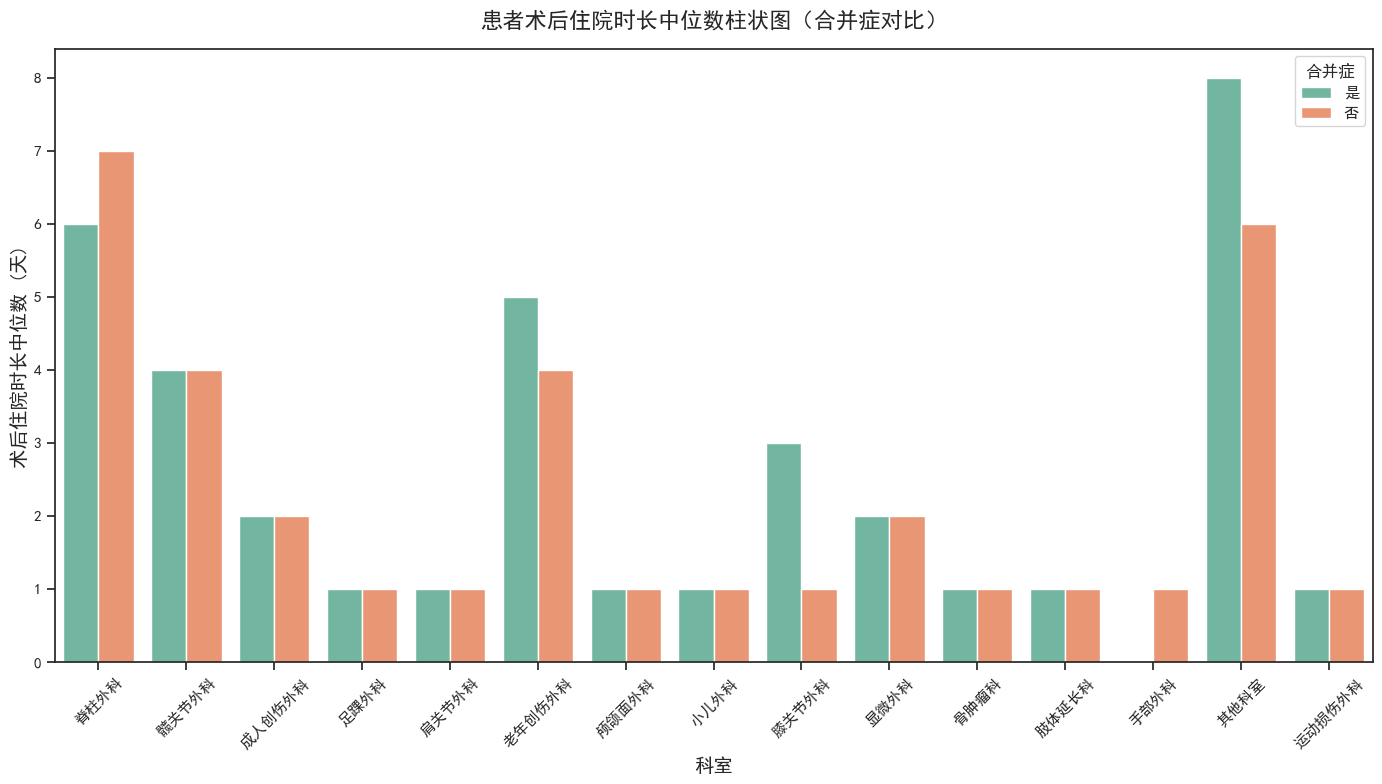

In [88]:
plt.figure(figsize=(14, 8)) 

ax = sns.barplot(
    x='科室', 
    y='POST_STAY', 
    data=df4, 
    estimator=np.median,
    hue='合并症',
    errorbar=None,          
    palette='Set2'    
)

plt.title("患者术后住院时长中位数柱状图（合并症对比）", fontsize=16, pad=15, fontweight='bold')
plt.ylabel("术后住院时长中位数 (天)", fontsize=14)
plt.xlabel("科室", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

U检验

In [89]:
from scipy.stats import mannwhitneyu

#分离出有无合并症的住院时长
group_0 = df4[df4['COMORBIDITIES'] == 0]['POST_STAY']
group_1 = df4[df4['COMORBIDITIES'] == 1]['POST_STAY']  

#确保两组都有足够的数据 
#H0：有无合并症的两组数据分布是相同的
#H1: 有无合并症的两组数据分布是不同的
if len(group_0) >= 5 and len(group_1) >= 5:        
#U检验
    U_stat, p_value = mannwhitneyu(group_1, group_0, alternative='two-sided') 
print(f"U-statistic: {U_stat:.4f}")
print(f"P-value: {p_value:.4f}")
alpha = 0.05  #显著性水平5%
if p_value < alpha:            
    print(f"P值 ({p_value:.4f}) 小于 {alpha}，拒绝原假设：即有无合并症的两组数据分布是不同的")
else:            
    print(f"P值 ({p_vlaue:.4f}) 大于或等于 {alpha}，无法拒绝原假设：有无合并症的两组数据分布是相同的")

U-statistic: 640453327.0000
P-value: 0.0000
P值 (0.0000) 小于 0.05，拒绝原假设：即有无合并症的两组数据分布是不同的


In [90]:
from scipy.stats import mannwhitneyu
u_test_results = [] #空列表
services = df4['科室'].dropna().unique() 
for i in services:
    subset = df4[df4['科室'] == i]
    #分离出有无合并症的住院时长
    group_0 = subset[subset['COMORBIDITIES'] == 0]['POST_STAY']
    group_1 = subset[subset['COMORBIDITIES'] == 1]['POST_STAY']
    #确保两组都有足够的数据    
    if len(group_0) >= 5 and len(group_1) >= 5:        
#U检验
        stat, p_value = mannwhitneyu(group_1, group_0, alternative='two-sided')        
#计算均值对比
        u_test_results.append({            
        'SERVICE': i,            
        'N_Without_Comord': len(group_0),            
        'N_With_Comorb': len(group_1),            
        'Median_POS_without': round(group_0.median(),2),            
        'Median_POS_With': round(group_1.median(),2),            
        'P_Value': round(p_value, 4),            
        # P < 0.05, 显著            
        'Significant': '显著' if p_value < 0.05 else '不显著'})            
#P值按照从小到大排序
df_u_test = pd.DataFrame(u_test_results)
df_u_test = df_u_test.sort_values(by='P_Value', ascending=True).reset_index(drop=True)
df_u_test

,SERVICE,N_Without_Comord,N_With_Comorb,Median_POS_without,Median_POS_With,P_Value,Significant
0,脊柱外科,1343,1469,7.0,6.0,0.0000,显著
1,足踝外科,3799,3509,1.0,1.0,0.0000,显著
2,肩关节外科,1861,2842,1.0,1.0,0.0000,显著
3,小儿外科,2684,1138,1.0,1.0,0.0000,显著
4,膝关节外科,3644,7350,1.0,3.0,0.0000,显著
5,手部外科,5285,6677,1.0,0.0,0.0000,显著
6,成人创伤外科,4643,2195,2.0,2.0,0.0135,显著
7,老年创伤外科,944,1849,4.0,5.0,0.0475,显著
8,颅颌面外科,1867,810,1.0,1.0,0.0979,不显著
9,骨肿瘤科,2209,1203,1.0,1.0,0.0980,不显著


#### 年龄

In [91]:
bins = [0, 18, 45, 65, 120]
labels = ['0-18(未成年)', '19-45(青壮年)', '46-65(中老年)', '65+(高龄/老年)']

df4['年龄分组'] = pd.cut(df4['AGE'], bins=bins, labels=labels, right=False)

# 年龄为空-Unknown
df4['年龄分组'] = df4['年龄分组'].cat.add_categories('未知').fillna('未知')

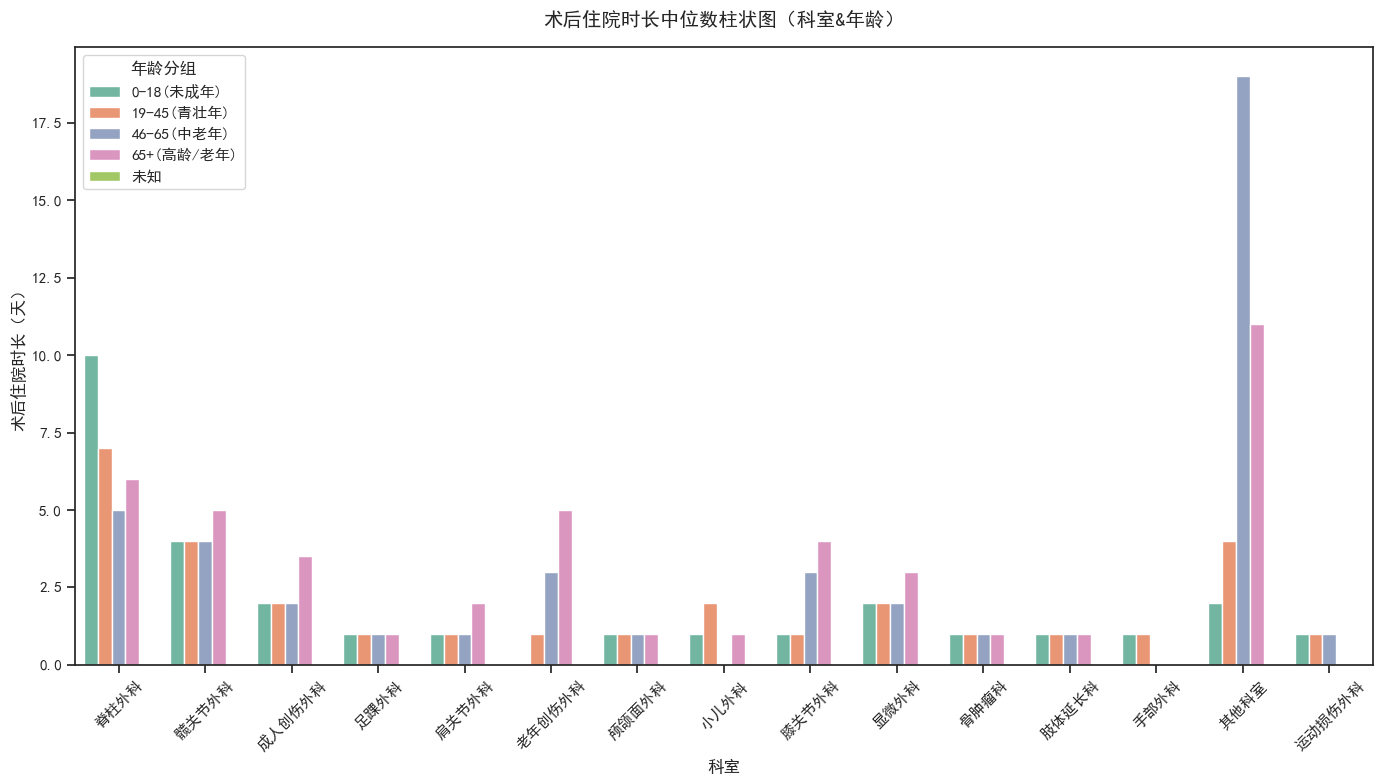

In [92]:
plt.figure(figsize=(14, 8))
sns.barplot(
    x='科室', 
    y='POST_STAY', 
    hue='年龄分组',
    data=df4, 
    errorbar=None, 
    palette='Set2',
    estimator=np.median  #计算中位数
)
plt.xticks(rotation=45)
plt.title("术后住院时长中位数柱状图（科室&年龄）", fontsize=14, pad=15)
plt.ylabel("术后住院时长（天）", fontsize=12)
plt.xlabel("科室", fontsize=12)
plt.tight_layout()
plt.show()

#### 疾病分组

In [93]:
df4['ICD_Final_Group'].value_counts()

ICD_Final_Group
骨骼肌肉系统疾病     29938
创伤与损伤        23392
神经系统疾病        5230
肿瘤及血液系统疾病     4275
先天性异常         3746
其他            2596
Name: count, dtype: int64

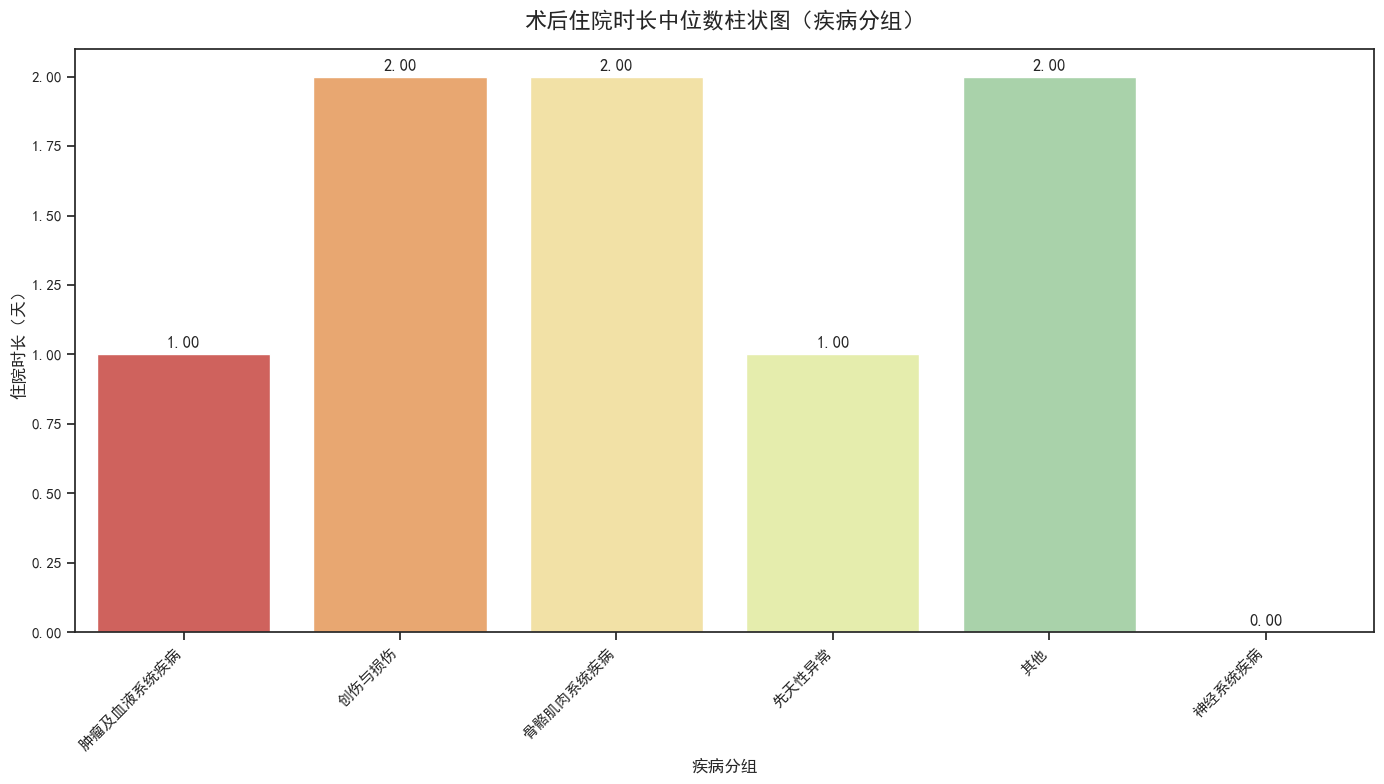

In [94]:
plt.figure(figsize = (14,8))
ax = sns.barplot(
    x='ICD_Final_Group',
    y='POST_STAY',
    data = df4,
    palette='Spectral',
    hue = 'ICD_Final_Group',
    estimator = np.median,
    errorbar= None 
)
for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3)    
plt.xticks(rotation=45,ha='right')
plt.title("术后住院时长中位数柱状图（疾病分组）", fontsize = 16, pad=15)
plt.xlabel("疾病分组", fontsize = 12)
plt.ylabel("住院时长（天）", fontsize=12)
plt.tight_layout()
plt.show()

* H检验

In [95]:
data_groups = []
service_list = df4['ICD_Final_Group'].unique()
for i in service_list:
    group = df4[df4['ICD_Final_Group'] == i]['POST_STAY']
    data_groups.append(group)
h_statistic, p_value = kruskal(*data_groups)
print(f"H-statistic: {h_statistic:.4f}")
print(f"P-value: {p_value:.4f}")
alpha = 0.05  #显著性水平5%
if p_value < alpha:        
    print(f"P值 ({p_value:.4f}) 小于 {alpha}，拒绝原假设: 即不同疾病分组的数据分布是不同的")
else:        
    print(f"P值 ({p_vlaue:.4f}) 大于或等于 {alpha}，无法拒绝原假设")

H-statistic: 9988.2285
P-value: 0.0000
P值 (0.0000) 小于 0.05，拒绝原假设: 即不同疾病分组的数据分布是不同的


In [96]:
h_test_icd = []
services = df4['科室'].dropna().unique()
for i in services:
    subset = df4[df4['科室'] == i].copy()    
    if len(subset) > 50:
        grouped_los = [group['POST_STAY'].values for name, group in subset.groupby('ICD_Final_Group') if len(group) > 0
]                
        
        if len(grouped_los) >= 2: 
            stat, p_value = kruskal(*grouped_los)    
            
            h_test_icd.append({                                
            '科室': i,                                
            'ICD_Groups_Count': len(grouped_los),                 
            'H_Statistic': round(stat, 4),                                
            'P_Value': round(p_value, 4),                                
            'Significant': '显著' if p_value < 0.05 else '不显著'                        
            })

df_h_test_icd = pd.DataFrame(h_test_icd)

if not df_h_test_icd.empty:    
# 按 P 值从小到大排序
    df_h_test_icd = df_h_test_icd.sort_values(by='P_Value', ascending=True).reset_index(drop=True)        
    display(df_h_test_icd)
else:        
    print("无法检验")

,科室,ICD_Groups_Count,H_Statistic,P_Value,Significant
0,脊柱外科,6,151.3478,0.0000,显著
1,髋关节外科,6,940.7878,0.0000,显著
2,成人创伤外科,6,121.0706,0.0000,显著
3,足踝外科,6,49.6138,0.0000,显著
4,肩关节外科,5,111.5865,0.0000,显著
5,颅颌面外科,6,72.5559,0.0000,显著
6,小儿外科,6,64.0227,0.0000,显著
7,显微外科,6,75.4256,0.0000,显著
8,骨肿瘤科,6,238.2808,0.0000,显著
9,肢体延长科,6,29.8839,0.0000,显著


#### 住院类型

In [97]:
df4['HOSPITALIZATION_TYPE'].unique()

array(['SURGICAL', 'INFECTION / POSTOPERATIVE COMPLICATION I ',
       'INACTIVE - MUNICIPALITY REGULATION - NIR ', nan, 'URGENCY',
       'CONTINUITY OF TREATMENT - CNRAC',
       'INACTIVE CONTINUITY OF TREATMENT - PDT', 'STATE REGULATION - NIR',
       'INACTIVE - TRANSFER ANOTHER HOSPITAL ',
       'INACTIVE - DAY HOSPITAL ',
       'INACTIVE -FRAT./LUX UP TO 3 WEEKS. DEM ESP ',
       'INACTIVE - CNRAC - TFD ', 'JUDICIAL ORDER',
       'INACTIVE - ORTHOPEDIC ', 'CLINICAL EMERGENCY',
       'CONTINUITY OF TREATMENT. - REMOVAL OF MAT. ', 'CNRAC',
       'INACTIVE INFRAT./LUX UP TO 3 SEM.TRANSFHOSP',
       'INACTIVE - TREAT COUNT. - INTERCURRENCE', 'HOME SERVICE'],
      dtype=object)

In [98]:
df4['HOSPITALIZATION_TYPE'] = df4['HOSPITALIZATION_TYPE'].str.strip()

In [99]:
df4['HOSPITALIZATION_TYPE'].unique()

array(['SURGICAL', 'INFECTION / POSTOPERATIVE COMPLICATION I',
       'INACTIVE - MUNICIPALITY REGULATION - NIR', nan, 'URGENCY',
       'CONTINUITY OF TREATMENT - CNRAC',
       'INACTIVE CONTINUITY OF TREATMENT - PDT', 'STATE REGULATION - NIR',
       'INACTIVE - TRANSFER ANOTHER HOSPITAL', 'INACTIVE - DAY HOSPITAL',
       'INACTIVE -FRAT./LUX UP TO 3 WEEKS. DEM ESP',
       'INACTIVE - CNRAC - TFD', 'JUDICIAL ORDER',
       'INACTIVE - ORTHOPEDIC', 'CLINICAL EMERGENCY',
       'CONTINUITY OF TREATMENT. - REMOVAL OF MAT.', 'CNRAC',
       'INACTIVE INFRAT./LUX UP TO 3 SEM.TRANSFHOSP',
       'INACTIVE - TREAT COUNT. - INTERCURRENCE', 'HOME SERVICE'],
      dtype=object)

In [100]:
type_mapping = {
    # 1. 择期手术
    'SURGICAL': '择期手术',
    'INACTIVE - ORTHOPEDIC': '择期手术',
    
    # 2. 急诊与创伤
    'URGENCY': '急诊与创伤',
    'CLINICAL EMERGENCY': '急诊与创伤',
    'INACTIVE -FRAT./LUX UP TO 3 WEEKS. DEM ESP': '急诊与创伤',
    'INACTIVE INFRAT./LUX UP TO 3 SEM.TRANSFHOSP': '急诊与创伤',
    
    # 3. 术后并发症
    'INFECTION / POSTOPERATIVE COMPLICATION I': '术后并发症',
    
    # 4. 计划连续治疗
    'CONTINUITY OF TREATMENT - CNRAC': '连续治疗',
    'INACTIVE CONTINUITY OF TREATMENT - PDT': '连续治疗',
    'CONTINUITY OF TREATMENT. - REMOVAL OF MAT.': '连续治疗',
    'INACTIVE - TREAT COUNT. - INTERCURRENCE': '连续治疗',
    'INACTIVE - DAY HOSPITAL': '连续治疗',
    
    # 5. 行政调配与转院
    'INACTIVE - MUNICIPALITY REGULATION - NIR': '行政调配与转院',
    'STATE REGULATION - NIR': '行政调配与转院',
    'INACTIVE - TRANSFER ANOTHER HOSPITAL': '行政调配与转院',
    'INACTIVE - CNRAC - TFD': '行政调配与转院',
    'CNRAC': '行政调配与转院',
    'JUDICIAL ORDER': '行政调配与转院',
    'HOME SERVICE': '行政调配与转院',
    
    # 6. 缺失值处理
    'Missing/Unknown': '缺失/未知'
}
df4['Hosp_Type_Clean'] = df4['HOSPITALIZATION_TYPE'].fillna('Missing/Unknown').map(type_mapping)
print(df4['Hosp_Type_Clean'].value_counts(dropna=False))

Hosp_Type_Clean
择期手术       29890
缺失/未知      23359
行政调配与转院     7996
急诊与创伤       3653
术后并发症       3338
连续治疗         941
Name: count, dtype: int64


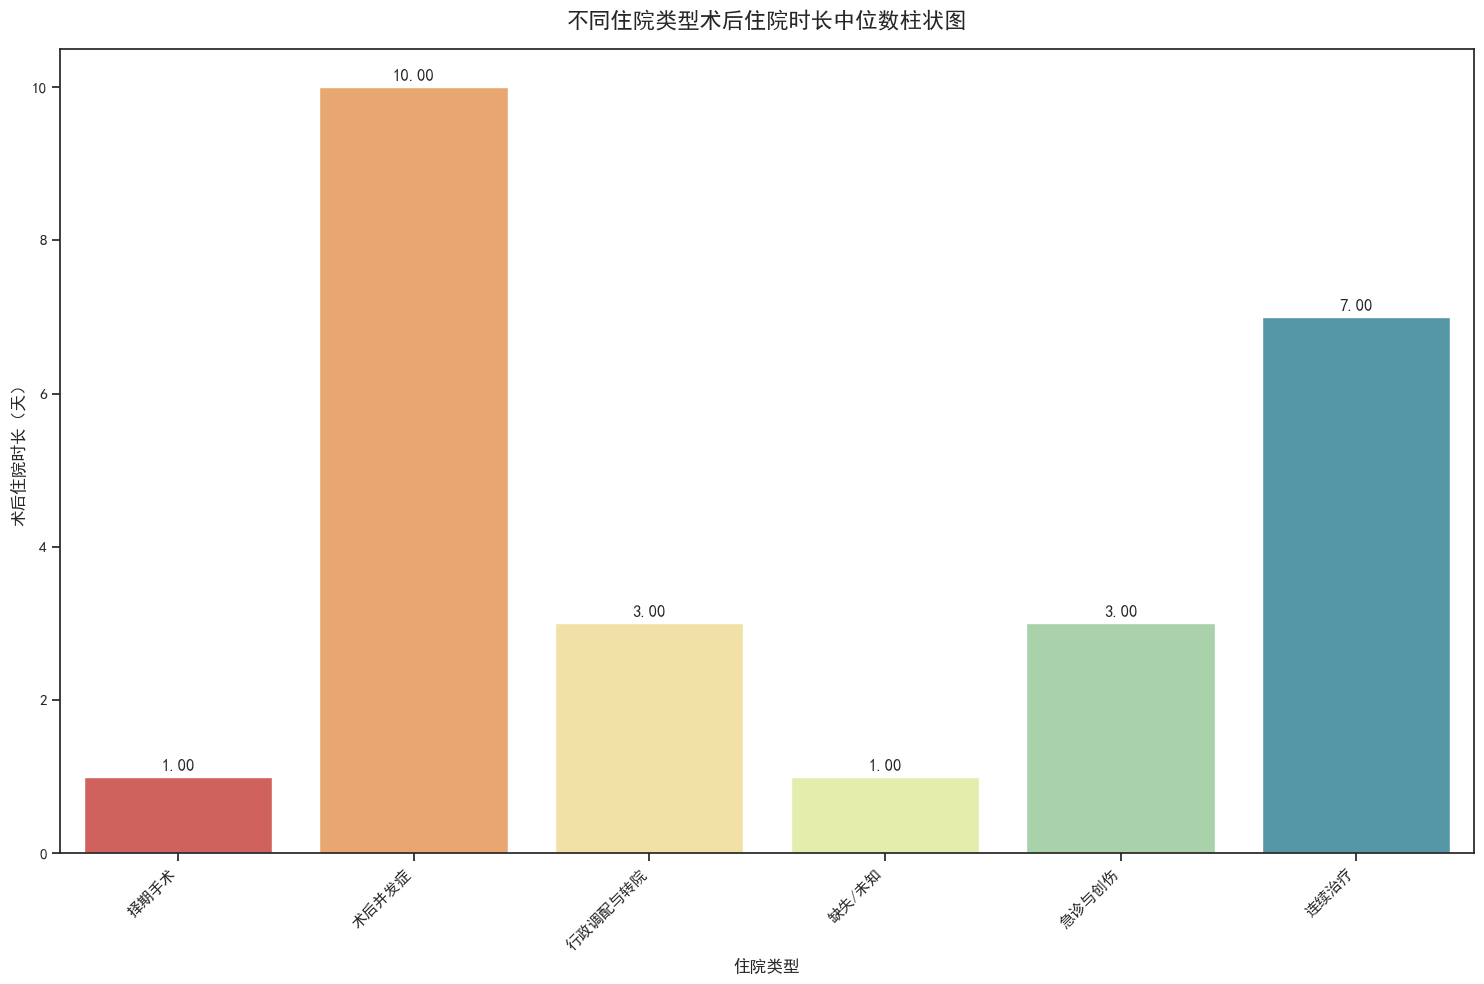

In [101]:
plt.figure(figsize = (15,10))
ax = sns.barplot(
    x='Hosp_Type_Clean',
    y='POST_STAY',
    data = df4,
    palette='Spectral',
    hue = 'Hosp_Type_Clean',
    estimator = np.median,
    errorbar= None 
)
for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3)    
plt.xticks(rotation=45,ha='right')
plt.title("不同住院类型术后住院时长中位数柱状图", fontsize = 16, pad=15)
plt.xlabel("住院类型", fontsize = 12)
plt.ylabel("术后住院时长（天）", fontsize=12)
plt.tight_layout()
plt.show()

* H检验

In [102]:
data_groups = []
service_list = df4['Hosp_Type_Clean'].unique()
for i in service_list:
    group = df4[df4['Hosp_Type_Clean'] == i]['POST_STAY']
    data_groups.append(group)
h_statistic, p_value = kruskal(*data_groups)
print(f"H-statistic: {h_statistic:.4f}")
print(f"P-value: {p_value:.4f}")
alpha = 0.05  #显著性水平5%
if p_value < alpha:            
    print(f"P值 ({p_value:.4f}) 小于 {alpha}，拒绝原假设: 即不同住院类型的数据分布是不同的")
else:            
    print(f"P值 ({p_vlaue:.4f}) 大于或等于 {alpha}，无法拒绝原假设")

H-statistic: 9644.5573
P-value: 0.0000
P值 (0.0000) 小于 0.05，拒绝原假设: 即不同住院类型的数据分布是不同的


In [103]:
h_test_icd = []
services = df4['科室'].dropna().unique()
for i in services:
    subset = df4[df4['科室'] == i].copy()        
    if len(subset) > 50:
        grouped_los = [group['POST_STAY'].values for name, group in subset.groupby('Hosp_Type_Clean') if len(group) > 0
]                                
        if len(grouped_los) >= 2: 
            stat, p_value = kruskal(*grouped_los)                
            h_test_icd.append({                                            
            'SERVICE': i,                                            
            'Hosp_Type_Clean_Count': len(grouped_los),                            
            'H_Statistic': round(stat, 4),                                            
            'P_Value': round(p_value, 4),                                            
            'Significant': '显著' if p_value < 0.05 else '不显著'                                    
})

df_h_test_icd = pd.DataFrame(h_test_icd)

if not df_h_test_icd.empty:    
# 按 P 值从小到大排序
    df_h_test_icd = df_h_test_icd.sort_values(by='P_Value', ascending=True).reset_index(drop=True)        
    display(df_h_test_icd)
else:            
    print("无法检验")

,SERVICE,Hosp_Type_Clean_Count,H_Statistic,P_Value,Significant
0,脊柱外科,6,227.2585,0.0000,显著
1,髋关节外科,6,1391.3900,0.0000,显著
2,成人创伤外科,6,939.7452,0.0000,显著
3,足踝外科,6,888.4336,0.0000,显著
4,肩关节外科,6,420.3451,0.0000,显著
5,老年创伤外科,6,340.3852,0.0000,显著
6,颅颌面外科,6,68.5561,0.0000,显著
7,小儿外科,6,417.9476,0.0000,显著
8,膝关节外科,6,704.0924,0.0000,显著
9,显微外科,6,322.6938,0.0000,显著


### 4. 多元回归分析

##### 对数右偏变量

In [104]:
count = (df4['Len_of_Stay'] < df4['TIME_UNTIL_1ST']).sum()
count

np.int64(1)

In [105]:
df4['POST_STAY'] = df4['POST_STAY'].clip(lower=0)

In [106]:
my_reg = df4.copy()
my_reg['Len_Of_Stay_log1p'] = np.log1p(df4['Len_of_Stay'])
my_reg['NUMBER_OF_SURGERIES_log1p'] = np.log1p(df4['NUMBER_OF_SURGERIES'])
my_reg['TIME_UNTIL_1st_log1p'] = np.log1p(df4['TIME_UNTIL_1ST'])
my_reg['POST_STAY_log1p'] = np.log1p(df4['POST_STAY'])

In [107]:
numeric_columns = my_reg.select_dtypes(include=[np.number]).columns
print(my_reg[numeric_columns].isnull().sum()) # nan的数量
print(np.isinf(my_reg[numeric_columns]).sum()) # inf的数量

AGE                          0
NUMBER_OF_SURGERIES          0
COMORBIDITIES                0
Len_of_Stay                  0
TIME_UNTIL_1ST               0
FORECAST_LOS                 0
DIFFERENCE_OF_DISCHARGE      0
POST_STAY                    0
SEX_encoded                  0
Len_Of_Stay_log1p            0
NUMBER_OF_SURGERIES_log1p    0
TIME_UNTIL_1st_log1p         0
POST_STAY_log1p              0
dtype: int64
AGE                          0
NUMBER_OF_SURGERIES          0
COMORBIDITIES                0
Len_of_Stay                  0
TIME_UNTIL_1ST               0
FORECAST_LOS                 0
DIFFERENCE_OF_DISCHARGE      0
POST_STAY                    0
SEX_encoded                  0
Len_Of_Stay_log1p            0
NUMBER_OF_SURGERIES_log1p    0
TIME_UNTIL_1st_log1p         0
POST_STAY_log1p              0
dtype: int64


##### 中心化

In [108]:
#对等待时间中心化
mean_time = my_reg['TIME_UNTIL_1st_log1p'].mean()
my_reg['TIME_log1p_centered'] = my_reg['TIME_UNTIL_1st_log1p'] - mean_time

#对手术次数进行中心化
mean_surg = my_reg['NUMBER_OF_SURGERIES_log1p'].mean()
my_reg['SURG_log1p_centered'] = my_reg['NUMBER_OF_SURGERIES_log1p'] - mean_surg

In [109]:
numeric_columns = my_reg.select_dtypes(include=[np.number]).columns
print(my_reg[numeric_columns].isnull().sum()) # nan的数量
print(np.isinf(my_reg[numeric_columns]).sum()) # inf的数量

AGE                          0
NUMBER_OF_SURGERIES          0
COMORBIDITIES                0
Len_of_Stay                  0
TIME_UNTIL_1ST               0
FORECAST_LOS                 0
DIFFERENCE_OF_DISCHARGE      0
POST_STAY                    0
SEX_encoded                  0
Len_Of_Stay_log1p            0
NUMBER_OF_SURGERIES_log1p    0
TIME_UNTIL_1st_log1p         0
POST_STAY_log1p              0
TIME_log1p_centered          0
SURG_log1p_centered          0
dtype: int64
AGE                          0
NUMBER_OF_SURGERIES          0
COMORBIDITIES                0
Len_of_Stay                  0
TIME_UNTIL_1ST               0
FORECAST_LOS                 0
DIFFERENCE_OF_DISCHARGE      0
POST_STAY                    0
SEX_encoded                  0
Len_Of_Stay_log1p            0
NUMBER_OF_SURGERIES_log1p    0
TIME_UNTIL_1st_log1p         0
POST_STAY_log1p              0
TIME_log1p_centered          0
SURG_log1p_centered          0
dtype: int64


##### 斯皮尔曼相关性

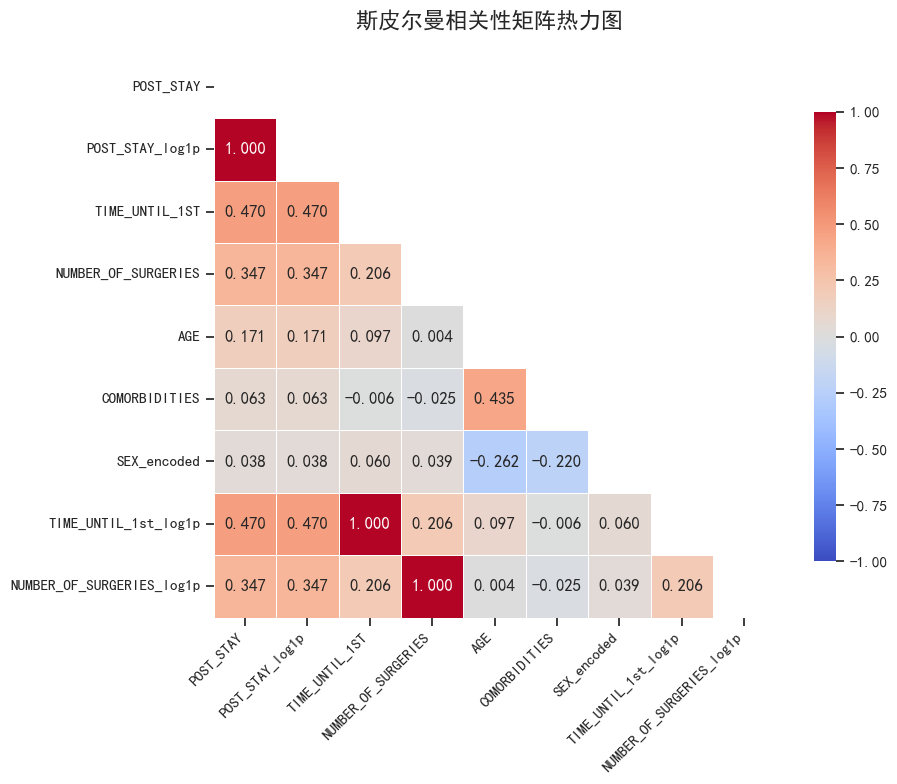

In [110]:
num_cols = ['POST_STAY', 'POST_STAY_log1p','TIME_UNTIL_1ST', 'NUMBER_OF_SURGERIES', 'AGE', 'COMORBIDITIES', 'SEX_encoded','TIME_UNTIL_1st_log1p', 'NUMBER_OF_SURGERIES_log1p',]
subset_corr = my_reg[num_cols].dropna()
corr_matrix = subset_corr.corr(method='spearman')
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
# 绘制热力图
sns.heatmap(
    corr_matrix, 
    mask=mask,                # 应用右上角遮蔽
    annot=True,               # 在方格里显示具体的系数数字
    fmt=".3f",                # 保留三位小数
    cmap='coolwarm',          # 红正相关，蓝负相关
    vmax=1, vmin=-1,      
    center=0,                 # 将 0 置于中间白色
    square=True,              # 正方形排版
    linewidths=.5,            # 格子之间增加细线
    cbar_kws={"shrink": .8}   # 缩小右侧颜色条的比例
)
plt.title("斯皮尔曼相关性矩阵热力图 ", fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()

#### 术后住院时长的影响因素

In [111]:
print(my_reg['SERVICE'].value_counts(dropna=False))
print("-" * 30)
print(my_reg['科室'].value_counts(dropna=False))

SERVICE
HAND                    11962
KNEE                    10994
HIP                      7474
FEET                     7308
ADULT TRAUMA             6838
SHOULDER                 4703
PEDIATRIC                3822
ONCOLOGY                 3412
SPINE                    2812
ELDERLY TRAUMA           2793
SKULL-MAXILLO-FACIAL     2677
LIMB LENGTHENING         2434
MICROSURGERY             1656
SPORT TRAUMA              176
Others                    116
Name: count, dtype: int64
------------------------------
科室
手部外科      11962
膝关节外科     10994
髋关节外科      7474
足踝外科       7308
成人创伤外科     6838
肩关节外科      4703
小儿外科       3822
骨肿瘤科       3412
脊柱外科       2812
老年创伤外科     2793
颅颌面外科      2677
肢体延长科      2434
显微外科       1656
运动损伤外科      176
其他科室        116
Name: count, dtype: int64


In [112]:
import statsmodels.formula.api as smf
model0 = smf.ols("POST_STAY_log1p ~ C(COMORBIDITIES) + AGE + C(SEX_encoded) + TIME_log1p_centered + SURG_log1p_centered", data=my_reg).fit()
print(model0.summary())

                            OLS Regression Results                            
Dep. Variable:        POST_STAY_log1p   R-squared:                       0.425
Model:                            OLS   Adj. R-squared:                  0.425
Method:                 Least Squares   F-statistic:                 1.022e+04
Date:                Sat, 02 May 2026   Prob (F-statistic):               0.00
Time:                        17:41:40   Log-Likelihood:                -72834.
No. Observations:               69177   AIC:                         1.457e+05
Df Residuals:                   69171   BIC:                         1.457e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.93

In [113]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
X_matrix = model0.model.exog
variable_names = model0.model.exog_names
# 计算所有特征的 VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = variable_names
vif_data["VIF"] = [variance_inflation_factor(X_matrix, i) for i in range(X_matrix.shape[1])]
# 过滤掉截距项并按 VIF降序
print(vif_data[vif_data["Feature"] != "Intercept"].sort_values(by="VIF", ascending=False))

                 Feature       VIF
3                    AGE  1.273341
1  C(COMORBIDITIES)[T.1]  1.239203
2    C(SEX_encoded)[T.1]  1.088741
4    TIME_log1p_centered  1.060643
5    SURG_log1p_centered  1.042440


In [114]:
import statsmodels.formula.api as smf
model1 = smf.ols("POST_STAY_log1p ~ C(COMORBIDITIES) + AGE + C(SEX_encoded) + C(Hosp_Type_Clean) + C(科室, Treatment(reference='成人创伤外科')) + TIME_log1p_centered + SURG_log1p_centered", data=my_reg).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:        POST_STAY_log1p   R-squared:                       0.572
Model:                            OLS   Adj. R-squared:                  0.572
Method:                 Least Squares   F-statistic:                     3855.
Date:                Sat, 02 May 2026   Prob (F-statistic):               0.00
Time:                        17:41:43   Log-Likelihood:                -62596.
No. Observations:               69177   AIC:                         1.252e+05
Df Residuals:                   69152   BIC:                         1.255e+05
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
                                                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

In [115]:
#急诊与创伤 基准组 3669 
#先天性异常  基准组   3748

共线性

In [116]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
X_matrix = model1.model.exog
variable_names = model1.model.exog_names
# 计算所有特征的 VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = variable_names
vif_data["VIF"] = [variance_inflation_factor(X_matrix, i) for i in range(X_matrix.shape[1])]
# 过滤掉截距项并按 VIF降序
print(vif_data[vif_data["Feature"] != "Intercept"].sort_values(by="VIF", ascending=False))

                                           Feature       VIF
3                       C(Hosp_Type_Clean)[T.择期手术]  5.721462
5                      C(Hosp_Type_Clean)[T.缺失/未知]  5.254129
6                    C(Hosp_Type_Clean)[T.行政调配与转院]  3.144497
10    C(科室, Treatment(reference='成人创伤外科'))[T.手部外科]  3.055405
16   C(科室, Treatment(reference='成人创伤外科'))[T.膝关节外科]  2.856961
..                                             ...       ...
7                       C(Hosp_Type_Clean)[T.连续治疗]  1.259022
2                              C(SEX_encoded)[T.1]  1.121212
24                             SURG_log1p_centered  1.092849
18  C(科室, Treatment(reference='成人创伤外科'))[T.运动损伤外科]  1.037981
8     C(科室, Treatment(reference='成人创伤外科'))[T.其他科室]  1.016728

[24 rows x 2 columns]


In [117]:
model2 = smf.ols("POST_STAY_log1p ~ C(COMORBIDITIES) + AGE + C(SEX_encoded)  + C(科室, Treatment(reference='成人创伤外科')) + TIME_log1p_centered + SURG_log1p_centered", data=my_reg).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:        POST_STAY_log1p   R-squared:                       0.542
Model:                            OLS   Adj. R-squared:                  0.542
Method:                 Least Squares   F-statistic:                     4307.
Date:                Sat, 02 May 2026   Prob (F-statistic):               0.00
Time:                        17:41:52   Log-Likelihood:                -64960.
No. Observations:               69177   AIC:                         1.300e+05
Df Residuals:                   69157   BIC:                         1.301e+05
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

In [118]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
X_matrix = model2.model.exog
variable_names = model2.model.exog_names
# 计算所有特征的 VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = variable_names
vif_data["VIF"] = [variance_inflation_factor(X_matrix, i) for i in range(X_matrix.shape[1])]
# 过滤掉截距项并按 VIF降序
print(vif_data[vif_data["Feature"] != "Intercept"].sort_values(by="VIF", ascending=False))

                                           Feature       VIF
5     C(科室, Treatment(reference='成人创伤外科'))[T.手部外科]  2.829706
11   C(科室, Treatment(reference='成人创伤外科'))[T.膝关节外科]  2.552554
12    C(科室, Treatment(reference='成人创伤外科'))[T.足踝外科]  2.106386
17                                             AGE  2.031231
16   C(科室, Treatment(reference='成人创伤外科'))[T.髋关节外科]  2.022305
4     C(科室, Treatment(reference='成人创伤外科'))[T.小儿外科]  1.774951
9    C(科室, Treatment(reference='成人创伤外科'))[T.肩关节外科]  1.733641
7   C(科室, Treatment(reference='成人创伤外科'))[T.老年创伤外科]  1.550984
15    C(科室, Treatment(reference='成人创伤外科'))[T.骨肿瘤科]  1.510631
14   C(科室, Treatment(reference='成人创伤外科'))[T.颅颌面外科]  1.405212
18                             TIME_log1p_centered  1.393010
10    C(科室, Treatment(reference='成人创伤外科'))[T.脊柱外科]  1.373927
8    C(科室, Treatment(reference='成人创伤外科'))[T.肢体延长科]  1.348211
6     C(科室, Treatment(reference='成人创伤外科'))[T.显微外科]  1.266116
1                            C(COMORBIDITIES)[T.1]  1.264597
2                       

+交互影响

In [119]:
my_reg['TIME_SURG_interaction'] = my_reg['TIME_log1p_centered'] * my_reg['SURG_log1p_centered']

In [120]:
import statsmodels.formula.api as smf
model3 = smf.ols("POST_STAY_log1p ~ C(COMORBIDITIES) + AGE + C(SEX_encoded) + C(Hosp_Type_Clean) + C(科室, Treatment(reference='成人创伤外科')) + TIME_log1p_centered + SURG_log1p_centered + TIME_SURG_interaction", data=my_reg).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:        POST_STAY_log1p   R-squared:                       0.573
Model:                            OLS   Adj. R-squared:                  0.573
Method:                 Least Squares   F-statistic:                     3713.
Date:                Sat, 02 May 2026   Prob (F-statistic):               0.00
Time:                        17:42:03   Log-Likelihood:                -62530.
No. Observations:               69177   AIC:                         1.251e+05
Df Residuals:                   69151   BIC:                         1.253e+05
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
                                                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

排查多重共线性

In [121]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_matrix = model3.model.exog
variable_names = model3.model.exog_names

# 计算所有特征的 VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = variable_names
vif_data["VIF"] = [variance_inflation_factor(X_matrix, i) for i in range(X_matrix.shape[1])]

# 过滤掉截距项并按 VIF降序
print(vif_data[vif_data["Feature"] != "Intercept"].sort_values(by="VIF", ascending=False))

                                           Feature       VIF
3                       C(Hosp_Type_Clean)[T.择期手术]  5.736550
5                      C(Hosp_Type_Clean)[T.缺失/未知]  5.263485
6                    C(Hosp_Type_Clean)[T.行政调配与转院]  3.144512
10    C(科室, Treatment(reference='成人创伤外科'))[T.手部外科]  3.068717
16   C(科室, Treatment(reference='成人创伤外科'))[T.膝关节外科]  2.857796
..                                             ...       ...
1                            C(COMORBIDITIES)[T.1]  1.272084
7                       C(Hosp_Type_Clean)[T.连续治疗]  1.259294
2                              C(SEX_encoded)[T.1]  1.121289
18  C(科室, Treatment(reference='成人创伤外科'))[T.运动损伤外科]  1.038070
8     C(科室, Treatment(reference='成人创伤外科'))[T.其他科室]  1.016742

[25 rows x 2 columns]


#### 最终模型

In [122]:
formula_final = "POST_STAY_log1p ~ COMORBIDITIES + AGE + C(SEX_encoded) + C(Hosp_Type_Clean) + C(科室, Treatment(reference='成人创伤外科')) + TIME_log1p_centered + SURG_log1p_centered + TIME_SURG_interaction"

model_final = smf.ols(formula_final, data=my_reg).fit()
print(model_final.summary())

                            OLS Regression Results                            
Dep. Variable:        POST_STAY_log1p   R-squared:                       0.573
Model:                            OLS   Adj. R-squared:                  0.573
Method:                 Least Squares   F-statistic:                     3713.
Date:                Sat, 02 May 2026   Prob (F-statistic):               0.00
Time:                        17:42:15   Log-Likelihood:                -62530.
No. Observations:               69177   AIC:                         1.251e+05
Df Residuals:                   69151   BIC:                         1.253e+05
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
                                                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

#### 评估拟合效果

In [ ]:
# 获取残差和拟合值
residuals = model_final.resid
fitted = model_final.fittedvalues
# 标准化残差
resid_standardized = model_final.get_influence().resid_studentized_internal

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. 残差 vs 拟合值 (查线性、同方差)
axes[0,0].scatter(fitted, residuals, alpha=0.3)
axes[0,0].axhline(y=0, color='r', linestyle='--')
axes[0,0].set_xlabel('Fitted Values')
axes[0,0].set_ylabel('Residuals')
axes[0,0].set_title('Residuals vs Fitted')

# 2. Scale-Location (查同方差，更敏感)
axes[0,1].scatter(fitted, np.sqrt(np.abs(resid_standardized)), alpha=0.3)
axes[0,1].set_xlabel('Fitted Values')
axes[0,1].set_ylabel('sqrt(|Standardized Residuals|)')
axes[0,1].set_title('Scale-Location')

# 3. Q-Q 图 (查正态性)
sm.qqplot(residuals, line='45', ax=axes[0,2])
axes[0,2].set_title('Q-Q Plot')

# 4. 残差直方图
axes[1,0].hist(residuals, bins=50, edgecolor='k')
axes[1,0].set_title('Residuals Histogram')

# 5. 残差 vs 顺序 
axes[1,1].scatter(range(len(residuals)), residuals, alpha=0.3)
axes[1,1].axhline(y=0, color='r', linestyle='--')
axes[1,1].set_xlabel('Observation Order')
axes[1,1].set_ylabel('Residuals')
axes[1,1].set_title('Residuals vs Order')

# 6. 库克距离 (查强影响点)
influence = model_final.get_influence()
cooks_dist = influence.cooks_distance[0]
axes[1,2].stem(cooks_dist, basefmt=" ")
axes[1,2].set_xlabel('Observation')
axes[1,2].set_ylabel("Cook's distance")
axes[1,2].set_title("Cook's Distance")

plt.tight_layout()
plt.show()

数据虽然存在明显的方差不齐（异方差）和非正态问题，但对于具有右偏和离散特征的医疗数据来说很常见。样本量足够大，没有严重拉偏结果的异常值，因此模型给出的各个变量的影响系数和重要性排名，在整体方向上依然是可靠的，只是算出来的标准误和 P 值不够准确。

#### 修正后最终模型

In [ ]:
formula_base = "POST_STAY_log1p ~ COMORBIDITIES + AGE + C(SEX_encoded) + C(Hosp_Type_Clean) + C(科室, Treatment(reference='成人创伤外科')) + TIME_log1p_centered + SURG_log1p_centered + TIME_SURG_interaction"
base_model = smf.ols(formula_final, data=my_reg).fit(cov_type='HC3')
print(base_model.summary())

* 该模型解释了术后住院时长变异的 57.3%。在复杂且差异的医疗临床数据中，不包含极度复杂非线性特征的基准线性模型达到 0.57 以上的解释度，说明选取的特征是准确的。

* 手术次数 (SURG_log1p_centered, coef = 3.2055)：最大的正向因素，意味着在其他条件不变的情况下，患者手术次数（对数值）每增加 1%，其术后住院时长会剧增约 3.2%。
* 术前等待时间 (TIME_log1p_centered, coef = 0.2668)：术前等待时间每增加 1%，术后住院时长会增加约 0.27%。
* 交互项（拮抗效应）：对于初次手术的患者（手术次数少），较长的术前等待时间会显著增加术后住院时长。但是，对于那些已经经历过多次手术的复杂患者（手术次数极多），等待时间拉长的负面冲击反而被削弱了

- 住院类型 (Hosp_Type_Clean)：
- 术后并发症 (coef = 0.4496)： 与基准类型相比，因术后并发症入院的患者，其术后住院时间显著延长。粗略估计延长了约 56.7%。
- 连续治疗 (coef = 0.4413)： 同样显著延长了约 55%。
- 择期手术 (coef = -0.2710)： 相比之下，有计划的择期手术患者，术后住院时间显著缩短了约 23.7%。

- 科室异质性 (科室)：
- 表中的参考基准是 成人创伤外科。
- 脊柱外科 (coef = 0.6768)： 系数最高，在控制了年龄、并发症等条件后，脊柱外科的术后住院时间比成人创伤外科长得多（约长 96%）。
- 手部外科 (coef = -0.5509)： 耗时最短的科室之一，比成人创伤外科短约 42.3%。属于精细但局部的手术，周转极快。

In [ ]:
result_list_final = []
params_dict = base_model.params.to_dict()

result_list_final.append({     
    'R-squared': round(model_final.rsquared, 3),                    
    '等待时间系数': params_dict.get('TIME_log1p_centered', 0),                                    
    '手术次数系数': params_dict.get('SURG_log1p_centered', 0),                                    
    '交互项系数': params_dict.get('TIME_SURG_interaction', 0),     
    '年龄系数': params_dict.get('AGE', 0),    
    '合并症系数': params_dict.get('COMORBIDITIES', 0),    
    '性别系数(男)': params_dict.get('C(SEX_encoded)[T.1]', 0),    
    
    # 住院类型
    '住院_择期手术': params_dict.get('C(Hosp_Type_Clean)[T.择期手术]', 0),    
    '住院_术后并发症': params_dict.get('C(Hosp_Type_Clean)[T.术后并发症]', 0),
    '住院_连续治疗': params_dict.get('C(Hosp_Type_Clean)[T.连续治疗]', 0),
    '住院_行政调配与转院': params_dict.get('C(Hosp_Type_Clean)[T.行政调配与转院]', 0),
    
    # 科室 (参考基准是成人创伤外科)
    '科室_脊柱外科': params_dict.get("C(科室, Treatment(reference='成人创伤外科'))[T.脊柱外科]", 0),
    '科室_髋关节外科': params_dict.get("C(科室, Treatment(reference='成人创伤外科'))[T.髋关节外科]", 0),
    '科室_显微外科': params_dict.get("C(科室, Treatment(reference='成人创伤外科'))[T.显微外科]", 0),
    '科室_其他科室': params_dict.get("C(科室, Treatment(reference='成人创伤外科'))[T.其他科室]", 0)
})

result_df = pd.DataFrame(result_list_final)
display(result_df)

In [ ]:
print(df4['TIME_UNTIL_1ST'].median())
print(df4['Len_of_Stay'].median())

以最典型的中位数（术前等待 1 天，术后住院 3 天）为例：术前每多等待 1 天，术后恢复期将客观延长约 0.46 天

#### 科室异质性检验

In [ ]:
formula_service = (    
'POST_STAY_log1p ~ COMORBIDITIES + AGE + C(SEX_encoded) + C(Hosp_Type_Clean)'    
'+ C(SERVICE) + TIME_log1p_centered + SURG_log1p_centered '
)
model5 = smf.ols(formula_service, data=my_reg).fit(cov_type='HC3')
# 主效应模型：不含科室
formula_main = (    
'POST_STAY_log1p ~ COMORBIDITIES + AGE + C(SEX_encoded) + C(Hosp_Type_Clean)'    
'+ TIME_log1p_centered + SURG_log1p_centered'
)
model_main = smf.ols(formula_main, data=my_reg).fit(cov_type='HC3')
# F检验（F-Test）
from statsmodels.stats.anova import anova_lm
lr_test = anova_lm(model_main, model5)
print(lr_test)

#### 交互项检验

In [ ]:
formula_full = (        
'POST_STAY_log1p ~ COMORBIDITIES + AGE + C(SEX_encoded) + C(Hosp_Type_Clean)'        
' + C(SERVICE) + TIME_log1p_centered + SURG_log1p_centered + TIME_SURG_interaction'
)
model_full = smf.ols(formula_full, data=my_reg).fit(cov_type='HC3')
# 主效应模型：不含交互项
formula_reduced = (        
'POST_STAY_log1p ~ COMORBIDITIES + AGE + C(SEX_encoded) + C(Hosp_Type_Clean) + '        
' C(SERVICE) + TIME_log1p_centered + SURG_log1p_centered'    
)
model_reduced = smf.ols(formula_reduced, data=my_reg).fit(cov_type='HC3')
# F检验（F-Test）
from statsmodels.stats.anova import anova_lm
lr_test = anova_lm(model_reduced, model_full)
print(lr_test)

#### 分科室回归

In [ ]:
results_list = []

formula_service = (    
    "POST_STAY_log1p ~ COMORBIDITIES + AGE + C(SEX_encoded) + C(Hosp_Type_Clean) + TIME_log1p_centered + SURG_log1p_centered + TIME_SURG_interaction"
)

services = my_reg['科室'].dropna().unique()

for service in services:
    subset = my_reg[my_reg['科室'] == service].copy()
    

    if len(subset) >= 100:
        try:
            model_service = smf.ols(formula_service, data=subset).fit(cov_type='HC3')
            print("="*60)
            print(f"{service}(样本量: {len(subset)})")
            print("="*60)
            print(model_service.summary()) 

            results_list.append({                
                '科室': service, 
                'R-squared': round(model_service.rsquared, 3),
                '等待时间系数': model_service.params.get('TIME_log1p_centered', 0),                
                '手术次数系数': model_service.params.get('SURG_log1p_centered', 0),                
                '交互项系数': model_service.params.get('TIME_SURG_interaction', 0),                 
                '等待时间p值': model_service.pvalues.get('TIME_log1p_centered', 1.0),                
                '手术次数p值': model_service.pvalues.get('SURG_log1p_centered', 1.0),                
                '交互项p值': model_service.pvalues.get('TIME_SURG_interaction', 1.0)            
                })
            
        except Exception as e:
            pass

In [ ]:
formula_1 = "Len_Of_Stay_log1p ~ COMORBIDITIES + AGE + C(SEX_encoded) + C(Hosp_Type_Clean) + C(科室, Treatment(reference='成人创伤外科')) + SURG_log1p_centered"
model_1 = smf.ols(formula_1, data=my_reg).fit()
print(model_1.summary())

共线性

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
X_matrix = model_1.model.exog
variable_names = model_1.model.exog_names
# 计算所有特征的 VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = variable_names
vif_data["VIF"] = [variance_inflation_factor(X_matrix, i) for i in range(X_matrix.shape[1])]
# 过滤掉截距项并按 VIF降序
print(vif_data[vif_data["Feature"] != "Intercept"].sort_values(by="VIF", ascending=False))

#### 可视化

In [ ]:
plt.figure(figsize=(10, 6)) 

df_all = pd.DataFrame(results_list).set_index('科室')

df_coef = df_all[['等待时间系数', '手术次数系数', '交互项系数']]
df_pval = df_all[['等待时间p值', '手术次数p值', '交互项p值']]

df_pval.columns = ['等待时间系数', '手术次数系数', '交互项系数'] 
sns.set_theme(style="white")
colors = ['#FF9800', '#F44336', '#1F4E79']

ax = df_coef.plot(kind='barh', figsize=(12, 9), color=colors, width=0.8, edgecolor='none')
plt.axvline(x=0, color='black', linewidth=1.5, linestyle='--')
cols = df_coef.columns.tolist()  # ['等待时间系数', '手术次数系数', '交互项系数'']

n_rows = len(df_coef)
for i, p in enumerate(ax.patches):
    col_idx = i // n_rows
    row_idx = i % n_rows    
    col_name = cols[col_idx]
    service_name = df_coef.index[row_idx]
    # 获取对应的 P 值    
    try:
        p_val = df_pval.loc[service_name, col_name]    
    except KeyError:        
        continue 

    # 确定显著性星号
    stars = ''    
    if p_val < 0.001:
        stars = '***'    
    elif p_val < 0.01:
        stars = '**'    
    elif p_val < 0.05:
        stars = '*'    
        
    if stars:
        val = p.get_width()     
        
        if pd.isna(val) or val == 0:            
            continue
        y_center = p.get_y() + p.get_height() / 2                
# 优化偏移量
        data_range = df_coef.values.max() - df_coef.values.min()
        offset = data_range * 0.01                
# 根据正负值决定对齐方式
        x_pos = val + offset if val >= 0 else val - offset
        ha_align = 'left' if val >= 0 else 'right'        
        ax.text(x_pos, y_center, stars, 
                va='center', ha=ha_align, 
                fontsize=11, fontweight='bold', color='black')

      
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']  
plt.rcParams['axes.unicode_minus'] = False

plt.title('关键连续变量及交互项对术后住院时长的影响效应（科室）', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('回归系数（影响程度）', fontsize=13)
plt.ylabel('科室', fontsize=13)
plt.legend(title='关键因素', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11)

# 去除顶部和右侧的边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
df_results = pd.DataFrame(results_list)

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(14, 11))

x_data = df_results['等待时间系数']
y_data = df_results['手术次数系数']
x_median = x_data.median()
y_median = y_data.median()

colors = []
for x, y in zip(x_data, y_data):
    if x >= x_median and y >= y_median:
        colors.append('#D32F2F') 
    elif x < x_median and y >= y_median:
        colors.append('#F57C00') 
    elif x < x_median and y < y_median:
        colors.append('#388E3C') 
    else:
        colors.append('#1976D2') 

plt.scatter(x_data, y_data, c=colors, s=250, alpha=0.8, edgecolor='white', zorder=3)
plt.axvline(x=x_median, color='gray', linestyle='--', linewidth=1.5, zorder=1)
plt.axhline(y=y_median, color='gray', linestyle='--', linewidth=1.5, zorder=1)

#添加文本标签 
for i in range(len(df_results)):
    dept_name = df_results.loc[i, '科室'].replace("外科", "")
    r2_val = df_results.loc[i, 'R-squared']
    
    label_text = f"{dept_name}\n(R平方={r2_val:.2f})"
    x_val, y_val = x_data.iloc[i], y_data.iloc[i]
    ha_align = 'left' if x_val >= x_median else 'right'
    va_align = 'bottom' if y_val >= y_median else 'top'
    x_offset = (x_data.max() - x_data.min()) * 0.015 * (1 if x_val >= x_median else -1)
    y_offset = (y_data.max() - y_data.min()) * 0.015 * (1 if y_val >= y_median else -1)

    plt.text(x_val + x_offset, y_val + y_offset, label_text, 
             fontsize=10, va=va_align, ha=ha_align, zorder=4,
             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.8))

box_style = dict(boxstyle='round,pad=0.5', facecolor='whitesmoke', edgecolor='gray', alpha=0.9)
x_min, x_max = plt.xlim()
y_min, y_max = plt.ylim()

plt.text(x_max*0.98, y_max*0.98, '双重影响', 
         fontsize=15, color='#D32F2F', ha='right', va='top', fontweight='bold', bbox=box_style, zorder=2)
plt.text(x_min*1.02, y_max*0.98, '医疗质量', 
         fontsize=15, color='#F57C00', ha='left', va='top', fontweight='bold', bbox=box_style, zorder=2)
plt.text(x_min*1.02, y_min*1.02, '其他因素', 
         fontsize=15, color='#388E3C', ha='left', va='bottom', fontweight='bold', bbox=box_style, zorder=2)
plt.text(x_max*0.98, y_min*1.02, '排程拥堵', 
         fontsize=15, color='#1976D2', ha='right', va='bottom', fontweight='bold', bbox=box_style, zorder=2)

plt.title('术后住院时长驱动因素矩阵（科室）', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('术前等待时间回归系数', fontsize=14)
plt.ylabel('手术次数回归系数', fontsize=14)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(True, linestyle=':', alpha=0.5, zorder=0)
plt.tight_layout()
plt.show()

#### 科室异质性分析（标准化）

In [ ]:
import scipy.stats as stats
import statsmodels.formula.api as smf
df_std = my_reg.copy()

cols_to_std = ['POST_STAY_log1p', 'TIME_log1p_centered', 'SURG_log1p_centered']

for col in cols_to_std:
    df_std[col] = stats.zscore(df_std[col], nan_policy='omit')

df_std['TIME_SURG_interaction_std'] = df_std['TIME_log1p_centered'] * df_std['SURG_log1p_centered']

formula_std = "POST_STAY_log1p ~ COMORBIDITIES + AGE + C(SEX_encoded) + C(Hosp_Type_Clean) + C(科室, Treatment(reference='成人创伤外科')) + TIME_log1p_centered + SURG_log1p_centered + TIME_SURG_interaction_std"

model_std = smf.ols(formula_std, data=df_std).fit(cov_type='HC3')
print(model_std.summary())

In [ ]:
results_list = []
formula_subgroup = (            
    "POST_STAY_log1p ~ COMORBIDITIES + AGE + C(SEX_encoded) + C(Hosp_Type_Clean) + TIME_log1p_centered + SURG_log1p_centered + TIME_SURG_interaction_std"
)

services = df_std['科室'].dropna().unique()

for service in services:
    subset = df_std[df_std['科室'] == service].copy()        
    
    if len(subset) >= 100:                
        try:
            model_service1 = smf.ols(formula_subgroup, data=subset).fit(cov_type='HC3')                               
            
            print("="*60)                        
            print(f"{service} (样本量: {len(subset)})")                        
            print("="*60)                        
            print(model_service1.summary())             
            
            # 提取数据
            results_list.append({                                            
                '科室': service,             
                'R-squared': round(model_service1.rsquared, 3),                            
                '等待时间系数': model_service1.params.get('TIME_log1p_centered', 0),                                            
                '手术次数系数': model_service1.params.get('SURG_log1p_centered', 0),                                         
                '交互项系数': model_service1.params.get('TIME_SURG_interaction_std', 0),                                             
                '等待时间p值': model_service1.pvalues.get('TIME_log1p_centered', 1.0),                                            
                '手术次数p值': model_service1.pvalues.get('SURG_log1p_centered', 1.0),                                            
                '交互项p值': model_service1.pvalues.get('TIME_SURG_interaction_std', 1.0)                                        
            })                 
        except Exception as e:                        
            print(f"{service} 回归失败，错误: {e}")

df_results = pd.DataFrame(results_list)
df_results

##### 可视化

In [ ]:
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']  
plt.rcParams['axes.unicode_minus'] = False

# 准备数据
df_all = pd.DataFrame(results_list).set_index('科室')

new_index = []
for dept in df_all.index:
    r2_val = df_all.loc[dept, 'R-squared']
    new_index.append(f"{dept} (R平方={r2_val:.2f})")

df_coef = df_all[['等待时间系数', '手术次数系数', '交互项系数']].copy()
df_coef.index = new_index

df_pval = df_all[['等待时间p值', '手术次数p值', '交互项p值']].copy()
df_pval.columns = ['等待时间系数', '手术次数系数', '交互项系数'] 
df_pval.index = new_index # p值的索引也必须同步更新，否则后面匹配不到


sns.set_theme(style="white")


plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']  
plt.rcParams['axes.unicode_minus'] = False

colors = ['#FF9800', '#F44336', '#1F4E79']
fig, ax = plt.subplots(figsize=(12, 10))
df_coef.plot(kind='barh', ax=ax, color=colors, width=0.8, edgecolor='none')

# 0基准线
plt.axvline(x=0, color='black', linewidth=1.5, linestyle='--')

# 显著性星号
cols = df_coef.columns.tolist()  
n_rows = len(df_coef)

for i, p in enumerate(ax.patches):
    col_idx = i // n_rows
    row_idx = i % n_rows    
    col_name = cols[col_idx]
    service_name = df_coef.index[row_idx]    
    
    # 获取P值        
    try:
        p_val = df_pval.loc[service_name, col_name]        
    except KeyError:                
        continue 
    
    # 确定显著性星号
    stars = ''        
    if p_val < 0.001:
        stars = '***'        
    elif p_val < 0.01:
        stars = '**'        
    elif p_val < 0.05:
        stars = '*'                
    
    if stars:
        val = p.get_width()                     
        if pd.isna(val) or val == 0:                        
            continue
        
        y_center = p.get_y() + p.get_height() / 2                
        # 优化偏移量
        data_range = df_coef.values.max() - df_coef.values.min()
        offset = data_range * 0.01                
        # 根据正负值决定对齐方式
        x_pos = val + offset if val >= 0 else val - offset
        ha_align = 'left' if val >= 0 else 'right'        
        
        ax.text(x_pos, y_center, stars, 
                va='center', ha=ha_align, 
                fontsize=11, fontweight='bold', color='black')
        
plt.title('关键因素及协同效应对术后住院时长影响的科室差异分析\n(标准化回归系数)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('标准 Beta 系数 (影响相对重要性)', fontsize=13)
plt.ylabel('科室及子模型解释力', fontsize=13)


plt.legend(title='关键因素', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
all_coefs_dict = {}

df_std = df_std.rename(columns={        
    'Hosp_Type_Clean': '住院类型',        
    'SEX_encoded': '性别编码',        
    'TIME_log1p_centered': '术前等待时间',        
    'SURG_log1p_centered': '手术次数',
    'TIME_SURG_interaction_std': '交互项'
})

formula_subgroup = (            
    "POST_STAY_log1p ~ COMORBIDITIES + AGE + C(性别编码) + C(住院类型) + 术前等待时间 + 手术次数 + 交互项")

services = df_std['科室'].dropna().unique()

for service in services:
    subset = df_std[df_std['科室'] == service]
    if len(subset) >= 100:                
        try:
            model = smf.ols(formula_subgroup, data=subset).fit(cov_type='HC3')
            coefs = model.params.drop('Intercept', errors='ignore')
            all_coefs_dict[service] = coefs
        except Exception as e:
            pass

df_all_coefs = pd.DataFrame(all_coefs_dict).T
df_all_coefs.head()

In [ ]:
df_abs = df_all_coefs.abs()
mask = df_abs.rank(axis=1, ascending=False) <= 4

df_top4 = df_all_coefs.where(mask)
df_top4 = df_top4.dropna(axis=1, how='all')

plt.figure(figsize=(12, 8)) 
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 画热力图
sns.heatmap(df_top4, annot=True, cmap='RdBu_r', center=0, 
            fmt=".2f", linewidths=.5, cbar_kws={'label': '标准 Beta 系数'},
            facecolor='whitesmoke') 

plt.title('各科室术后住院时长关键驱动因素热力图（标准化回归系数Top4）', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('特征', fontsize=13)
plt.ylabel('科室', fontsize=13)

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### 5. 亚组、稳健性分析

#### 合并症的亚组分析

In [ ]:

results = []

formula_subgroup = (
    "POST_STAY_log1p ~ AGE + C(SEX_encoded) + C(Hosp_Type_Clean) + "
    "C(科室, Treatment(reference='成人创伤外科')) + "
    "TIME_log1p_centered + SURG_log1p_centered + TIME_SURG_interaction"
)

cols_to_check = [
    'POST_STAY_log1p', 'TIME_log1p_centered', 'SURG_log1p_centered', 
    'TIME_SURG_interaction', 'COMORBIDITIES', 'AGE', 'SEX_encoded', 
    'Hosp_Type_Clean', '科室'
]

for comorb in [0, 1]:
    subset = my_reg[my_reg['COMORBIDITIES'] == comorb].copy()
    subset = subset.dropna(subset=cols_to_check)
    
    if len(subset) > 100:
        model = smf.ols(formula_subgroup, data=subset).fit(cov_type='HC3')        
        
        coef_time = model.params.get('TIME_log1p_centered', np.nan)
        pval_time = model.pvalues.get('TIME_log1p_centered', np.nan)
        
        coef_surg = model.params.get('SURG_log1p_centered', np.nan)
        pval_surg = model.pvalues.get('SURG_log1p_centered', np.nan)   
        
        coef_int = model.params.get('TIME_SURG_interaction', np.nan)
        pval_int = model.pvalues.get('TIME_SURG_interaction', np.nan)
        
        results.append({            
            '合并症分组': '有合并症 (1)' if comorb == 1 else '无合并症 (0)',            
            '样本量': len(subset),            
            '等待时间_系数': round(coef_time, 4),            
            '等待时间_P值': round(pval_time, 4),            
            '手术次数_系数': round(coef_surg, 4),            
            '手术次数_P值': round(pval_surg, 4),
            '交互项_系数': round(coef_int, 4),            
            '交互项_P值': round(pval_int, 4)
        })                
        
        print(f"\n 合并症 = {comorb} (样本量: {len(subset)}) ===")        
        print(f"  等待时间主效应 (TIME): {coef_time:.4f} (p={pval_time:.4f})")        
        print(f"  手术次数主效应 (SURG): {coef_surg:.4f} (p={pval_surg:.4f})") 
        print(f"  交互效应 (TIME*SURG): {coef_int:.4f} (p={pval_int:.4f})")
    else:        
        print(f"\n合并症 = {comorb}: 样本 {len(subset)} < 100, 跳过.")

df_results = pd.DataFrame(results)
print("\n--- 合并症分层分析结果对比 ---")
df_results

亚组分析揭示了患者基础健康状况对住院周期的影响。\
首先，健康人群的术后住院期对纯行政性等待更为敏感（系数 0.2784 > 0.2516），提示对于无合并症的常规择期手术，应极致压缩术前等待以释放床位。\
其次，虽然随着手术次数的增加，两组患者对等待时间的敏感度均出现边际递减（负向交互项），但伴有合并症的脆弱群体表现出更弱的缓冲能力（-0.1946 vs -0.3721）。这意味着，对于需要进行多次手术的复杂基础病患者，漫长的术前等待与反复的手术创伤会形成更强烈的叠加消耗。

#### 合并症/术后并发症因果次序

In [ ]:
#去除合并症
model_without_c = smf.ols("POST_STAY_log1p ~ AGE + C(SEX_encoded) + C(Hosp_Type_Clean) + "    
"C(科室, Treatment(reference='成人创伤外科')) + "    
"TIME_log1p_centered + SURG_log1p_centered + TIME_SURG_interaction"
, data=my_reg).fit(cov_type='HC3')
print(model_without_c.summary())

In [ ]:
df_post = my_reg[my_reg['Hosp_Type_Clean'] != '术后并发症'].copy()

# 用筛选后的数据拟合
model_no_unknown = smf.ols(    
"POST_STAY_log1p ~ COMORBIDITIES + AGE + C(SEX_encoded) + C(Hosp_Type_Clean) + "    
"C(科室, Treatment(reference='成人创伤外科')) + "    
"TIME_log1p_centered + SURG_log1p_centered + TIME_SURG_interaction",
data=df_post).fit(cov_type='HC3')
print(model_no_unknown.summary())

* 术前等待时间 (TIME) 的系数在  0.2598 - 0.2670 之间微幅波动。
* 手术次数 (SURG) 的系数在 3.2054 到 3.3945 之间波动。
* 交互项 (TIME_SURG_interaction) 的系数在 -0.2867 到 -0.3090 之间波动。
* 这三个核心变量的 P 值始终保持在 0.000。\
这证明了“等待时间与手术次数存在负向交互（边际效用递减）”这一核心规律，不依赖于特定高危人群（并发症人群）的存在。\
无论手术是否顺利，这个规律在全院层面具有极强的普适性和稳健性。

#### 对住院类型存在2w+缺失值敏感性分析

In [ ]:
df_hos_clean = my_reg[my_reg['Hosp_Type_Clean'] != '缺失/未知'].copy()

# 用筛选后的数据重新拟合模型
model_no_unknown = smf.ols(
    "POST_STAY_log1p ~ COMORBIDITIES + AGE + C(SEX_encoded) + C(Hosp_Type_Clean) + "    
"C(科室, Treatment(reference='成人创伤外科')) + "    
"TIME_log1p_centered + SURG_log1p_centered + TIME_SURG_interaction",
    data= df_hos_clean).fit(cov_type='HC3')

print(model_no_unknown.summary())

In [ ]:
df_merged = my_reg.copy()
#将'缺失/未知'替换为'择期手术'
df_merged['Hosp_Type_Clean'] = df_merged['Hosp_Type_Clean'].replace('缺失/未知', '择期手术')
print(df_merged['Hosp_Type_Clean'].value_counts())

model_merged = smf.ols(
    "POST_STAY_log1p ~ COMORBIDITIES + AGE + C(SEX_encoded) + C(Hosp_Type_Clean) + "    
"C(科室, Treatment(reference='成人创伤外科')) + "    
"TIME_log1p_centered + SURG_log1p_centered + TIME_SURG_interaction",data=df_merged).fit(cov_type='HC3')

print(model_merged.summary())

考虑到本数据集中‘入院类型（Hosp_Type_Clean）’存在约 2 万例的缺失/未知记录，为排除缺失数据处理方式对研究结论的潜在干扰，进行了两项敏感性测试。
* 首先，进行完整病例分析，直接剔除缺失样本（保留 N=45,818）。结果显示，模型的解释力进一步提升至 59.0%，且等待时间、手术次数及其交互项的系数保持高度稳定与极度显著（p<0.001）。
* 其次，使用插补法，将缺失值归类为最多数群体‘择期手术’以保留全样本（N=69,177）。在此假设下，核心参数的估计值几乎未发生偏移。
综上，本项目识别出的核心临床驱动因素及其交互作用，对缺失数据的处理策略不敏感，具有极强的统计学稳健性与普适性。

### 6. 其他因素

In [ ]:
df4['REASON_GROUPED'].value_counts()

In [ ]:
plt.figure(figsize = (12,7))
ax = sns.barplot(
    x='REASON_GROUPED',
    y='Len_of_Stay',
    data = df4,
    palette='Spectral',
    hue = 'REASON_GROUPED',
    estimator = np.median,
    errorbar= None 
)
for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3)
    
plt.xticks(rotation=45,ha='right')
plt.title("不同出院原因住院时长中位数柱状图", fontsize = 16, pad=15)
plt.xlabel("出院原因", fontsize = 12)
plt.ylabel("住院时长（天）", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import kruskal

In [ ]:
data_groups = []
service_list = df4['REASON_GROUPED'].unique()
for i in service_list:
    group = df4[df4['REASON_GROUPED'] == i]['Len_of_Stay']
    data_groups.append(group)
h_statistic, p_value = kruskal(*data_groups)
print(f"H-statistic: {h_statistic:.4f}")
print(f"P-value: {p_value:.4f}")
alpha = 0.05  # 显著性水平5%
if p_value < alpha:        
    print(f"P值 ({p_value:.4f}) 小于 {alpha}，拒绝原假设：即不同出院原因的数据分布有显著不同")
else:        
    print(f"P值 ({p_vlaue:.4f}) 大于或等于 {alpha}，无法拒绝原假设")

In [ ]:
df4['转院地点'].value_counts()

In [ ]:
plt.figure(figsize = (12,7))
ax = sns.barplot(
    x='转院地点',
    y='Len_of_Stay',
    data = df4,
    palette='Spectral',
    hue = '转院地点',
    estimator = np.median,
    errorbar= None 
)
for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3)    
plt.xticks(rotation=45,ha='right')
plt.title("不同转院地点住院时长中位数柱状图", fontsize = 16, pad=15)
plt.xlabel("住院类型", fontsize = 12)
plt.ylabel("住院时长（天）", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import kruskal
data_groups = []
service_list = df4['转院地点'].unique()
for i in service_list:
    group = df4[df4['转院地点'] == i]['Len_of_Stay']
    data_groups.append(group)
h_statistic, p_value = kruskal(*data_groups)
print(f"H-statistic: {h_statistic:.4f}")
print(f"P-value: {p_value:.4f}")
alpha = 0.05  # 显著性水平5%
if p_value < alpha:            
    print(f"P值 ({p_value:.4f}) 小于 {alpha}，拒绝原假设：即不同转院地点的数据分布有显著不同")
else:            
    print(f"P值 ({p_vlaue:.4f}) 大于或等于 {alpha}，无法拒绝原假设")

### 7. 预测偏差分析

In [ ]:
df4.groupby('科室')['FORECAST_LOS'].describe().sort_values(by ='mean', ascending = False)

In [ ]:
plt.figure(figsize=(14, 8))
ax= sns.barplot(
    x='科室', 
    y='FORECAST_LOS', 
    hue='科室',
    data=df4, 
    errorbar=None, 
    palette='Set2',
    estimator=np.median  #计算中位数
)

for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3)    
    
plt.xticks(rotation=45)
plt.title("预测住院时长中位数柱状图（科室）", fontsize=14, pad=15)
plt.ylabel("预测住院时长（天）", fontsize=12)
plt.xlabel("科室", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
df4.groupby('科室')['DIFFERENCE_OF_DISCHARGE'].describe()

In [ ]:
plt.figure(figsize=(14, 8))
ax= sns.barplot(
    x='科室', 
    y='DIFFERENCE_OF_DISCHARGE', 
    hue='科室',
    data=df4, 
    errorbar=None, 
    palette='Set2',
    estimator=np.median  #计算中位数
)
for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3)        
plt.xticks(rotation=45)
plt.title("预测住院时长偏差中位数柱状图（科室）", fontsize=14, pad=15)
plt.ylabel("预测住院时长偏差（天）", fontsize=12)
plt.xlabel("科室", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(14, 8))
ax= sns.barplot(
    x='科室', 
    y='DIFFERENCE_OF_DISCHARGE', 
    hue='科室',
    data=df4, 
    errorbar=None, 
    palette='Set2',
    estimator=np.mean  #计算中位数
)
for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3)        
plt.xticks(rotation=45)
plt.title("平均预测住院时长偏差柱状图（科室）", fontsize=14, pad=15)
plt.ylabel("预测住院时长偏差（天）", fontsize=12)
plt.xlabel("科室", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(14, 8))

ax = sns.countplot(
    x='科室',
    data=df4,
    palette='Set2',
    hue = '科室'
)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.xticks(rotation=45)
plt.title("各科室住院人数", fontsize=14)
plt.ylabel("人数", fontsize=12)
plt.xlabel("科室", fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
df_delay = df4[df4['DIFFERENCE_OF_DISCHARGE'] >= 0] 

In [ ]:
total_wasted_days = df_delay['DIFFERENCE_OF_DISCHARGE'].sum() 
print(f"非预期滞留总天数：{total_wasted_days} 天")

In [ ]:
delayed_patients_count = len(df_delay)

# 超期率
total_patients = len(df4)
delay_rate = (delayed_patients_count / total_patients) * 100

print(f"发生超期的总人数：{delayed_patients_count} 人")
print(f"全院超期率：{delay_rate:.2f}%")

In [ ]:
plt.figure(figsize=(14, 8))
ax= sns.barplot(
    x='科室', 
    y='DIFFERENCE_OF_DISCHARGE', 
    hue='科室',
    data=df_delay, 
    errorbar=None, 
    palette='Set2',
    estimator=np.median  #计算中位数
)
for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3)        
plt.xticks(rotation=45)
plt.title("预测住院时长偏差中位数柱状图（超期）", fontsize=14, pad=15)
plt.ylabel("预测住院时长偏差（天）", fontsize=12)
plt.xlabel("科室", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
df_outliers = df4[df4['DIFFERENCE_OF_DISCHARGE'] > 3].copy()
df4['is_outlier'] = (df4['DIFFERENCE_OF_DISCHARGE'] > 3).astype(int)
df_delay = len(df_outliers) / len(df4) * 100
print(f"离群患者共 {len(df_outliers)} 人。")
print(f"全院患者共 {len(df4)} 人。")
print(f"离群患者占比{df_delay:.2f}%")

In [ ]:
df4['is_outlier_pct'] = df4['is_outlier'] * 100

In [ ]:
plt.figure(figsize=(14, 8))
ax= sns.barplot(
    x='科室', 
    y='is_outlier_pct', 
    hue='科室',
    data=df4, 
    errorbar=None, 
    palette='Set2'
)
for container in ax.containers:
        ax.bar_label(container, fmt='%.2f%%', padding=3) 
    
plt.xticks(rotation=45)
plt.title("各科室预测超期3天患者比例柱状图", fontsize=14, pad=15)
plt.ylabel("超期 3 天的患者比例 (%)", fontsize=12)
plt.xlabel("科室", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
#0-4是周一到周五，5-6是周六周日
df4['day_of_week'] = pd.to_datetime(df4['ADMISSION_DATE']).dt.dayofweek
df4['is_weekend'] = df4['day_of_week'].map(lambda x: 1 if x >= 5 else 0)

# 更新筛选出的离群组
df_outliers = df4[df4['is_outlier'] == 1]

In [ ]:

features_to_check = ['ICD_Final_Group', 'Hosp_Type_Clean', 'SEX_encoded', 'is_weekend','科室', 'COMORBIDITIES', 'AGE', '转院地点', 'REASON_GROUPED',
                    'TIME_UNTIL_1st_log1p', 'NUMBER_OF_SURGERIES_log1p'] 

results = []

for col in features_to_check:
    if col in df4.columns:
        dist = df4.groupby('is_outlier')[col].value_counts(normalize=True).unstack().fillna(0)
        for category in dist.columns:
            try:
                normal_pct = dist.loc[0, category] * 100  # 正常组中的占比 (%)
                outlier_pct = dist.loc[1, category] * 100 # 超期组中的占比 (%)
                
                diff = outlier_pct - normal_pct
                
                results.append({
                    '特征维度': col,
                    '具体类别': category,
                    '正常人群占比(%)': normal_pct,
                    '超期占比(%)': outlier_pct,
                    '异常差异(%)': diff
                })
            except KeyError:
                pass

#
df_suspects = pd.DataFrame(results)

# “超期组”异常偏高的特征
print("高发特征Top5:")
top_suspects = df_suspects.sort_values(by='异常差异(%)', ascending=False).head(5)
print(top_suspects.to_string(index=False, float_format="%.2f"))

print("\n" + "="*50 + "\n")

# “超期组”异常偏低的特征
print("免疫特征Top5:")
safe_suspects = df_suspects.sort_values(by='异常差异(%)', ascending=True).head(5)
print(safe_suspects.to_string(index=False, float_format="%.2f"))

In [ ]:
df_suspects_map = {
    'Hosp_Type_Clean': '住院类型',            
    'ICD_Final_Group': '疾病分组'
}
df_suspects['特征维度'] = df_suspects['特征维度'].replace(df_suspects_map)

df_suspects['显示标签'] = df_suspects['特征维度'] + ': ' + df_suspects['具体类别'].astype(str)
top_to_plot = df_suspects.sort_values(by='异常差异(%)', ascending=False).head(8)

plt.figure(figsize=(12, 8))


ax = sns.barplot( 
    x='显示标签',       
    y='异常差异(%)',    
    data=top_to_plot,  
    errorbar=None,
    hue='显示标签',
    palette='Reds_r'    
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=3)

plt.xlabel("核心致延特征", fontsize=12)
plt.ylabel("导致超期的异常差异 (%)", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=11) 
plt.title('导致非预期超期的患者核心特征画像 (Top 8)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

* 创伤类疾病

In [ ]:
trauma_df = df4[df4['ICD_Final_Group'].str.contains('创伤', na=False) | 
                df4['科室'].str.contains('创伤', na=False)].copy()

trauma_profile = trauma_df.groupby('is_outlier')[['TIME_UNTIL_1ST', 'NUMBER_OF_SURGERIES']].median()

print("创伤类患者对比 (0=正常, 1=超期) ---")
print(trauma_profile.round(2))

* 行政调配与转院（上游/下游）

In [ ]:
transfer_vs_elective = df4[df4['Hosp_Type_Clean'].isin(['行政调配与转院', '择期手术'])]

transfer_profile1 = transfer_vs_elective.groupby('Hosp_Type_Clean').agg(
    平均等待时间_TIME=('TIME_UNTIL_1ST', 'mean'),
    平均手术次数=('NUMBER_OF_SURGERIES', 'mean'),
    合并症比例=('COMORBIDITIES', 'mean'), 
    平均超期天数=('DIFFERENCE_OF_DISCHARGE', 'mean')
)

transfer_profile2 = transfer_vs_elective.groupby('Hosp_Type_Clean').agg(
    平均等待时间_TIME=('TIME_UNTIL_1ST', 'median'),
    平均手术次数=('NUMBER_OF_SURGERIES', 'median'),
    合并症比例=('COMORBIDITIES', 'median'), 
    平均超期天数=('DIFFERENCE_OF_DISCHARGE', 'median')
)

print("转院患者 vs 择期患者对比(均值)")
print(transfer_profile1.round(2))
print("转院患者 vs 择期患者对比(中位数)")
print(transfer_profile2.round(2))


In [ ]:
transfer_df = df4[df4['Hosp_Type_Clean'] == '行政调配与转院']

transfer_target = transfer_df.groupby('科室').agg(
    转院接收人数=('is_outlier', 'count'),
    平均等待时间=('TIME_UNTIL_1ST', 'mean'),
    中位数等待时间=('TIME_UNTIL_1ST', 'median'),
    平均超期天数=('DIFFERENCE_OF_DISCHARGE', 'mean'),
    中位数超期天数=('DIFFERENCE_OF_DISCHARGE', 'median')
).sort_values(by='转院接收人数', ascending=False)

print("转院患者接收科室排行")
print("\n" + "-"*60 + "\n")
print(transfer_target.head(5))

print("\n" + "="*60 + "\n")

transfer_disease = transfer_df.groupby('ICD_Final_Group').agg(
    转院接收人数=('is_outlier', 'count'),
    平均等待时间=('TIME_UNTIL_1ST', 'mean'),
    中位数等待时间=('TIME_UNTIL_1ST', 'median')
).sort_values(by='转院接收人数', ascending=False)

print("转院患者疾病分组排行")
print("\n" + "-"*60 + "\n")
print(transfer_disease.head(5))

创伤类（成人/老年创伤外科）承接了全院超 60% 的转院负荷，其平均 5-7 天的术前等待是导致住院超期的核心诱因。

髋关节外科接收的转院患者呈现出极端的低效特征（术前等待超9天，总超期近20天）,该科室在应对复杂转诊病例时，存在严重的围手术期评估瓶颈。

In [ ]:
df4['入院年份'] = df4['ADMISSION_DATE'].dt.year

missing_type_df = df4[df4['Hosp_Type_Clean'] == '缺失/未知']
missing_by_year = missing_type_df['入院年份'].value_counts().sort_index()
total_by_year = df4['入院年份'].value_counts().sort_index()
missing_rate_by_year = (missing_by_year / total_by_year * 100).fillna(0)

print("各年度 Hosp_Type 缺失率 (%)")
print(missing_rate_by_year.round(1))
print("缺失记录最多的 Top 3 科室")
print(missing_type_df['科室'].value_counts(normalize=True).head(3).round(3) * 100)

##### 转院地点

In [ ]:
delayed_df = df4[df4['is_outlier'] == 1]
transfer_dest_dist = delayed_df['转院地点'].value_counts(normalize=True) * 100
print("超期患者的转院地点分布 (%) ")
print(transfer_dest_dist.round(2).head(10)) # 只看Top10去向

##### 术后并发症

In [ ]:
comp_df = df4[df4['Hosp_Type_Clean'] == '术后并发症']
comp_pivot = comp_df.groupby('科室').agg(
    并发症人数=('is_outlier', 'count'), # 这里只是借用一列来计数
    平均超期天数=('DIFFERENCE_OF_DISCHARGE', 'mean')
).sort_values(by='并发症人数', ascending=False)

print("术后并发症高发科室")
print(comp_pivot.head(5))

### 8. 运营优化模拟

In [ ]:
# 计算原始状态下的总天数
# 注：总天数 = 原始术前等待时间 + 预测的术后时间
current_post_stay_pred_log = model_final.predict(my_reg)
current_post_stay_days = np.expm1(current_post_stay_pred_log).sum()
current_wait_days = my_reg['TIME_UNTIL_1ST'].sum()
current_total_hospital_days = current_wait_days + current_post_stay_days

# 假设全院术前等待时间缩短 20%
scenario_df = my_reg.copy()
scenario_df['TIME_New'] = scenario_df['TIME_UNTIL_1ST'] * 0.8  

# 对新等待时间进行变换
# original_time_mean是TIME_UNTIL_1st_log1p 的均值
original_time_mean = my_reg['TIME_UNTIL_1st_log1p'].mean() 
scenario_df['TIME_log1p_new'] = np.log1p(scenario_df['TIME_New'])
scenario_df['TIME_log1p_centered'] = scenario_df['TIME_log1p_new'] - original_time_mean

# 更新交互项
# 用新的等待时间重算交互项
scenario_df['TIME_SURG_interaction'] = scenario_df['TIME_log1p_centered'] * scenario_df['SURG_log1p_centered']

# 预测优化后的术后天数
optimized_post_stay_pred_log = model_final.predict(scenario_df)
optimized_post_stay_days = np.expm1(optimized_post_stay_pred_log).sum()

# 计算优化后的总天数 (新的术前 + 预测的新术后)
optimized_wait_days = scenario_df['TIME_New'].sum()
optimized_total_hospital_days = optimized_wait_days + optimized_post_stay_days

# 计算效益
total_days_saved = current_total_hospital_days - optimized_total_hospital_days
wait_reduction = current_wait_days - optimized_wait_days
post_stay_reduction = current_post_stay_days - optimized_post_stay_days

roi_percentage = (total_days_saved / current_total_hospital_days) * 100

print(f"当前总住院天数: {current_total_hospital_days:.0f} 天")
print(f"优化后总住院天数: {optimized_total_hospital_days:.0f} 天")
print(f"总节省天数: {total_days_saved:.0f} 天")
print(f"  - 其中术前缩短(直接贡献): {wait_reduction:.0f} 天")
print(f"  - 其中术后缩短(协同贡献): {post_stay_reduction:.0f} 天")
print(f"整体流转效率提升: {roi_percentage:.2f}%")

In [ ]:
my_reg['入院年份'] = my_reg['ADMISSION_DATE'].dt.year

In [ ]:
yearly_patients = my_reg['入院年份'].value_counts().sort_index()
print("各年度收治患者总数：")
print(yearly_patients)

In [ ]:
yearly_los_trend1 = my_reg.groupby('入院年份')['Len_of_Stay'].mean()
yearly_los_trend2 = my_reg.groupby('入院年份')['Len_of_Stay'].median()
print(yearly_los_trend1)
print(yearly_los_trend2)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(yearly_los_trend1.index, yearly_los_trend1.values, marker='o', color='#2b7bba', linewidth=2)

plt.title('全院平均住院时长年度趋势', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('年份', fontsize=12)
plt.ylabel('平均住院时长 (天)', fontsize=12)
plt.xticks(yearly_los_trend1.index) 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
my_reg.groupby('入院年份')['Len_of_Stay'].describe()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(yearly_los_trend2.index, yearly_los_trend2.values, marker='o', color='#2b7bba', linewidth=2)
plt.title('全院住院时长年度趋势（中位数）', fontsize=15, fontweight='bold', pad=15)

plt.xlabel('年份', fontsize=12)
plt.ylabel('中位数住院时长 (天)', fontsize=12)
plt.xticks(yearly_los_trend2.index) 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
df_outliers = df4[df4['DIFFERENCE_OF_DISCHARGE'] > 3].copy()
df_outliers['入院年份'] = df_outliers['ADMISSION_DATE'].dt.year
yearly_los1 = df_outliers.groupby('入院年份')['Len_of_Stay'].mean()
yearly_los2 = df_outliers.groupby('入院年份')['Len_of_Stay'].median()
plt.figure(figsize=(10, 6))
plt.plot(yearly_los1.index, yearly_los1, marker='o', color='#2b7bba', linewidth=2)
plt.title('延迟患者平均住院时长年度趋势', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('年份', fontsize=12)
plt.ylabel('平均住院时长 (天)', fontsize=12)
plt.xticks(yearly_los1.index) 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(yearly_los2.index, yearly_los2, marker='o', color='#2b7bba', linewidth=2)
plt.title('延迟患者住院时长年度趋势（中位数）', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('年份', fontsize=12)
plt.ylabel('平均住院时长 (天)', fontsize=12)
plt.xticks(yearly_los2.index) 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
df_outliers = df4[df4['DIFFERENCE_OF_DISCHARGE'] > 3].copy()
df_outliers.groupby('入院年份')['Len_of_Stay'].describe()